<a href="https://colab.research.google.com/github/gmatiushkov/suai-iadnomo-coursework-8-sem/blob/main/%D0%9A%D0%9F_%D0%98%D0%90%D0%94_%D0%9C%D0%B0%D1%82%D1%8E%D1%88%D0%BA%D0%BE%D0%B2%D0%93%D0%9F_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D0%BD%D1%82_27_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Группа 4232

Матюшков Григорий Петрович

Вариант 27:

Ансамбль нейронных сетей типа бэггинг на основе сверточной нейросетевой модели с полносвязным классификатором.

Установка библиотек

In [ ]:
!pip install -U scikeras scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 22.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency reso

Импорты

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential, regularizers, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.ensemble import BaggingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils import class_weight, check_random_state
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Загрузка данных

In [ ]:
# Загрузка данных по предоставленным ссылкам
df = pd.read_excel("https://raw.githubusercontent.com/gmatiushkov/suai-iadnomo-coursework-8-sem/refs/heads/main/MKA_TMI_labels.xls", index_col=0)
df_unlabeled = pd.read_csv("https://raw.githubusercontent.com/gmatiushkov/suai-iadnomo-coursework-8-sem/refs/heads/main/MKA_04.2015_unlabeled.csv", index_col=0)

## Переразметка данных для бинарной классификации

Исходный размер датасета: (2679, 49)
Уникальные значения в столбце 'Class': [0 2 1]

Распределение классов до переразметки:
Class
0    2356
1     218
2     105
Name: count, dtype: int64

После переразметки:
Уникальные значения в столбце 'Class': [0 1]

Распределение классов после переразметки:
Class
0    2356
1     323
Name: count, dtype: int64


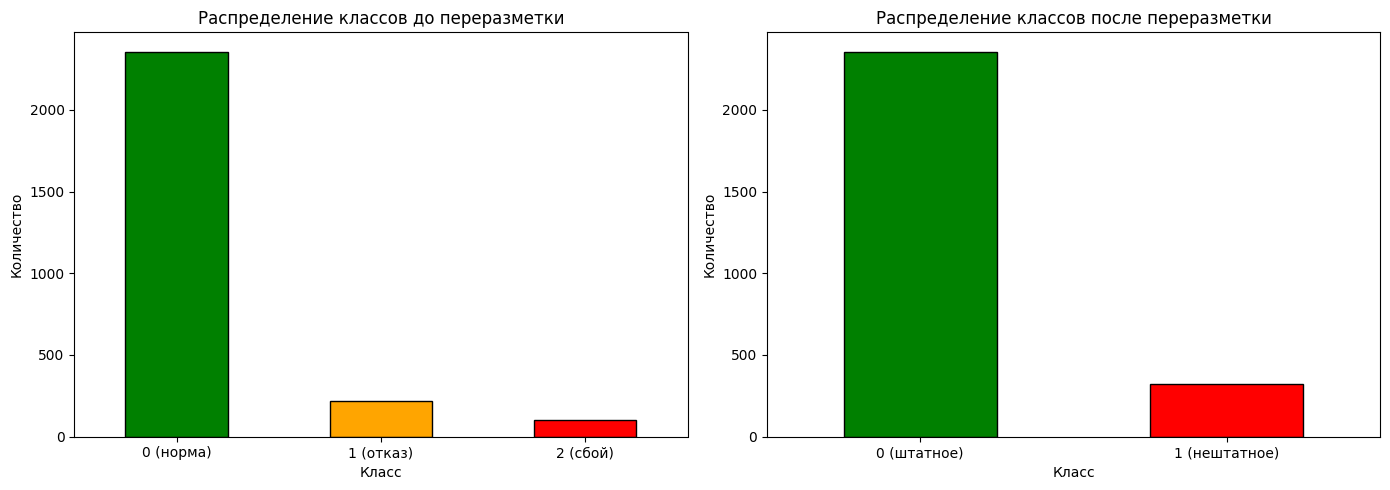

In [ ]:
print(f"Исходный размер датасета: {df.shape}")
print(f"Уникальные значения в столбце 'Class': {df['Class'].unique()}")
print("\nРаспределение классов до переразметки:")
print(df['Class'].value_counts().sort_index())

df_binary = df.copy()
df_binary['Class'] = df_binary['Class'].replace({2: 1})

print("\n" + "="*60)
print("После переразметки:")
print(f"Уникальные значения в столбце 'Class': {df_binary['Class'].unique()}")
print("\nРаспределение классов после переразметки:")
print(df_binary['Class'].value_counts().sort_index())

# визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До переразметки
df['Class'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['green', 'orange', 'red'], edgecolor='black'
)
axes[0].set_title('Распределение классов до переразметки')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(['0 (норма)', '1 (отказ)', '2 (сбой)'], rotation=0)

# После переразметки
df_binary['Class'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['green', 'red'], edgecolor='black'
)
axes[1].set_title('Распределение классов после переразметки')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
axes[1].set_xticklabels(['0 (штатное)', '1 (нештатное)'], rotation=0)

plt.tight_layout()
plt.show()

## Разведочный анализ данных

Информация о датасете

In [ ]:
df_binary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2679 entries, 14.83 to 14.56
Data columns (total 49 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ibs,A    2679 non-null   float64
 1   Isun,A   2679 non-null   float64
 2   Ipt1,A   2679 non-null   float64
 3   Ipt2,A   2679 non-null   float64
 4   Ipt3,A   2679 non-null   float64
 5   Ipt4,A   2679 non-null   float64
 6   Ipt5,A   2679 non-null   float64
 7   Ipt6,A   2679 non-null   float64
 8   Ipt7,A   2679 non-null   float64
 9   Ipt10,A  2679 non-null   float64
 10  Ipt11,A  2679 non-null   float64
 11  Ipt12,A  2679 non-null   float64
 12  Ipt13,A  2679 non-null   float64
 13  Ipt14,A  2679 non-null   float64
 14  Ipt15,A  2679 non-null   float64
 15  Ipt16,A  2679 non-null   float64
 16  Ipt17,A  2679 non-null   float64
 17  TR1,C    2679 non-null   int64  
 18  TR2,C    2679 non-null   int64  
 19  TR3,C    2679 non-null   int64  
 20  TR4,C    2679 non-null   int64  
 21  TR5,C    2679 

Размер и описательные статистики

In [ ]:
print(f"Размер: {df_binary.shape}")
print("\nСтолбцы:")
print(df_binary.columns.tolist())
print("\nЦелевой столбец: Class")

print("\nСтатистика")
print(df_binary.describe())

Размер: (2679, 49)

Столбцы:
['Ibs,A', 'Isun,A', 'Ipt1,A', 'Ipt2,A', 'Ipt3,A', 'Ipt4,A', 'Ipt5,A', 'Ipt6,A', 'Ipt7,A', 'Ipt10,A', 'Ipt11,A', 'Ipt12,A', 'Ipt13,A', 'Ipt14,A', 'Ipt15,A', 'Ipt16,A', 'Ipt17,A', 'TR1,C', 'TR2,C', 'TR3,C', 'TR4,C', 'TR5,C', 'TR6,C', 'TR7,C', 'TR8,C', 'TR9,C', 'TR10,C', 'TR11,C', 'TR12,C', 'TR13,C', 'TR14,C', 'TR15,C', 'TR16,C', 'TDS1,C', 'TDS2,C', 'TDS3,C', 'TDS4,C', 'TDS5,C', 'TDS6,C', 'TDS7,C', 'TDS8,C', 'TDS9,C', 'TKpt,C', 'TGbv,C', 'TNap,C', 'TPrd2,C', 'TPrd1,C', 'TDS24,C', 'Class']

Целевой столбец: Class

Статистика
             Ibs,A       Isun,A       Ipt1,A       Ipt2,A       Ipt3,A  \
count  2679.000000  2679.000000  2679.000000  2679.000000  2679.000000   
mean      0.681149     0.744246     0.301657     0.304169     0.205778   
std       1.078681     0.997524     0.806005     0.792725     0.783437   
min       0.110000     0.000000     0.040000     0.000000     0.000000   
25%       0.210000     0.000000     0.070000     0.070000     0.000000   


Можно видеть, что null-значения в датасете отсутствуют, что является плюсом. Все данные числовые: либо float64, либо int64. Тип данных целевого столбца – int64. Датасет размером 49 столбцов (48 признаков и целевой столбец Class) на 2679 строк и занимает 1 Мб. Наблюдается большой дисбаланс классов, что необходимо учитывать при оценке моделей.

## Корреляционные матрицы и их визуализации

Корреляционные подматрицы

In [ ]:
columns = df_binary.columns.tolist()
target_column = 'Class'

# 0-11 + Class
subset_1_cols = columns[0:12] + [target_column]
df_subset_1 = df_binary[subset_1_cols]
corr_matrix_1 = df_subset_1.corr()

# 12-23 + Class
subset_2_cols = columns[12:24] + [target_column]
df_subset_2 = df_binary[subset_2_cols]
corr_matrix_2 = df_subset_2.corr()

# 24-35 + Class
subset_3_cols = columns[24:36] + [target_column]
df_subset_3 = df_binary[subset_3_cols]
corr_matrix_3 = df_subset_3.corr()

# 36-47 + Class
subset_4_cols = columns[36:48] + [target_column]
df_subset_4 = df_binary[subset_4_cols]
corr_matrix_4 = df_subset_4.corr()

Тепловая карта 1

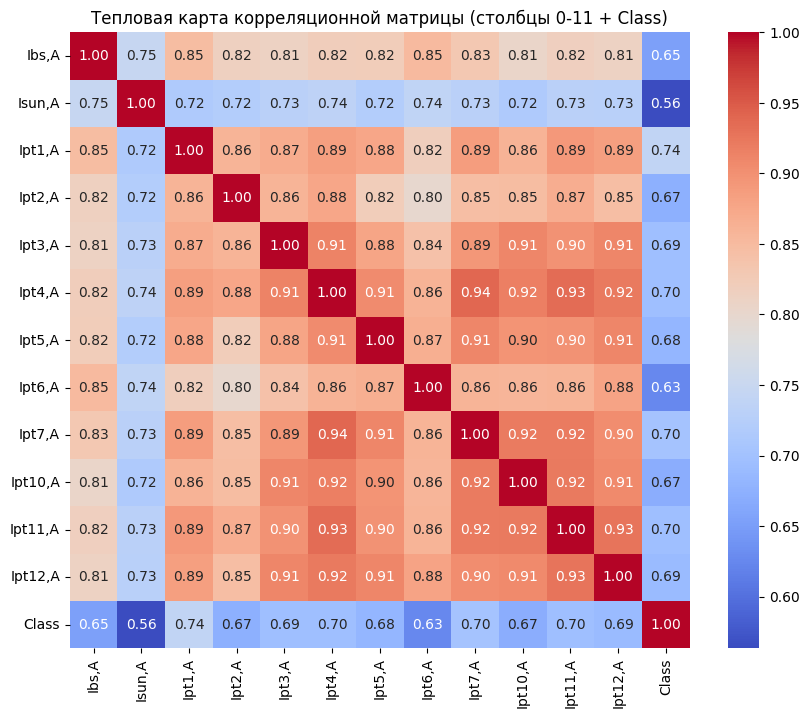

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляционной матрицы (столбцы 0-11 + Class)')
plt.show()

Тепловая карта 2

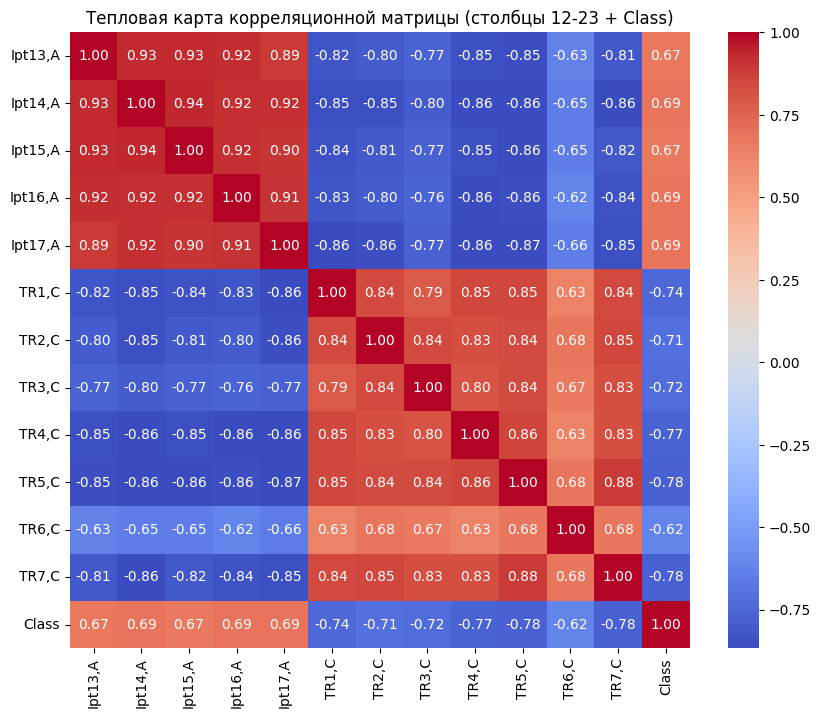

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляционной матрицы (столбцы 12-23 + Class)')
plt.show()

Тепловая карта 3

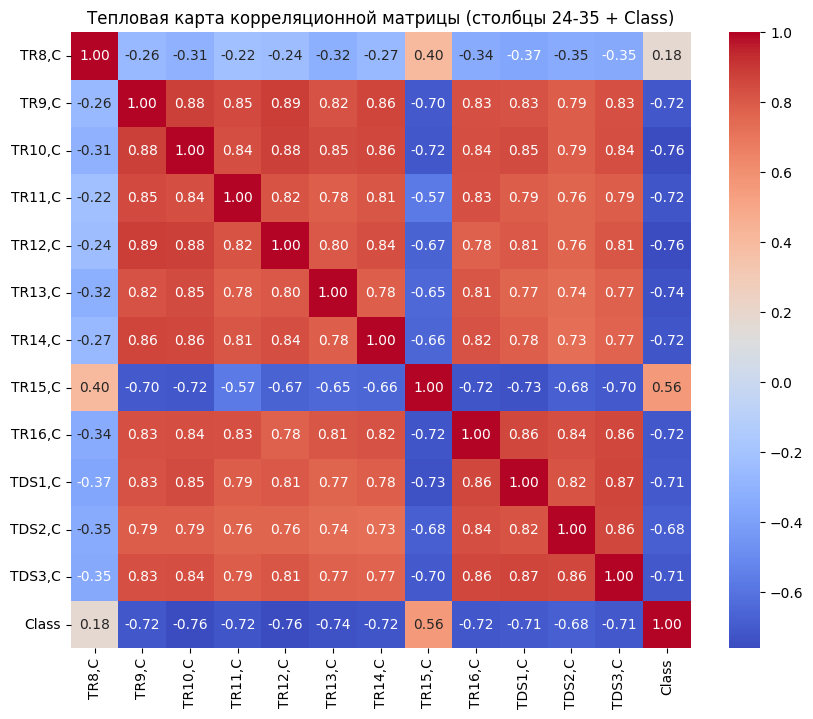

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляционной матрицы (столбцы 24-35 + Class)')
plt.show()

Тепловая карта 4

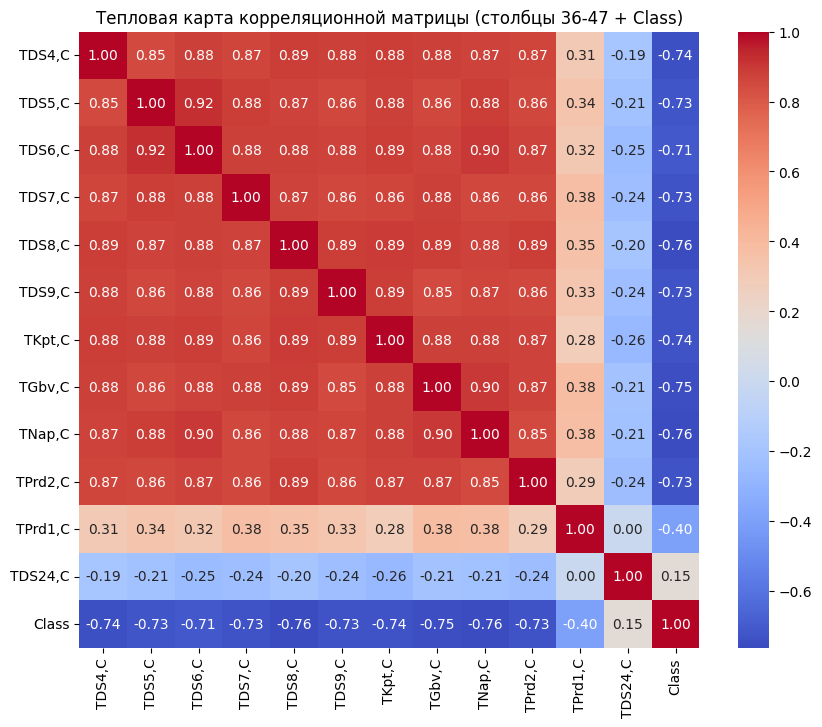

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_4, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляционной матрицы (столбцы 36-47 + Class)')
plt.show()

**1\.** Положительная корреляция: Ipt1,A, Ipt7,A, Ipt4,A, Ipt11,A, Ipt3,A, Ipt12,A, Ipt5,A, Ipt10,A, Ipt2,A, Ibs,A, Ipt6,A, Isun,A показывают умеренную и сильную положительную корреляцию с классом. Это означает, что при увеличении значений этих признаков, вероятность принадлежности к классу '1' (нештатное состояние) возрастает.

**2\.** Положительная корреляция: Ipt16,A, Ipt14,A, Ipt17,A, Ipt13,A, Ipt15,A также демонстрируют умеренную и сильную положительную корреляцию с классом.

Отрицательная корреляция: TR7,C, TR1,C, TR3,C, TR5,C, TR6,C, TR4,C, TR2,C имеют умеренную и сильную отрицательную корреляцию. Это говорит о том, что при уменьшении значений этих признаков возрастает вероятность принадлежности к классу '1'.

**3\.** Положительная корреляция: TR15,C показывает умеренную положительную корреляцию.

Отрицательная корреляция: TR10,C, TR12,C, TR11,C, TR9,C, TR14,C, TR13,C, TR16,C, TDS3,C, TDS2,C, TDS1,C имеют сильную отрицательную корреляцию. Это указывает на то, что чем ниже значения этих признаков, тем выше вероятность нештатного состояния.

**4\.** Отрицательная корреляция: TDS8,C, TDS4,C, TKpt,C, TDS7,C, TDS5,C, TDS9,C, TDS6,C, TGbv,C, TNap,C показывают сильную отрицательную корреляцию. TPrd1,C также имеет умеренную отрицательную корреляцию.
Положительная корреляция: TDS24,C демонстрирует слабую положительную корреляцию.


В целом, многие признаки, особенно связанные с 'TR' и 'TDS', имеют сильную отрицательную корреляцию с целевым классом, что означает, что их снижение может быть индикатором нештатного состояния. Признаки, начинающиеся с 'Ipt', как правило, положительно коррелируют с целевым классом.

Посмотрим на матрицу рассеяния для 7 признаков, которые наиболее коррелируют с целевым столбцом


Топ-7 признаков

In [ ]:
correlations_abs = df_binary.corr()['Class'].abs().sort_values(ascending=False)
top_7_features = correlations_abs[1:8].index.tolist()

print(f"Топ-7 наиболее коррелирующих признаков с 'Class': {top_7_features}")

df_top_features = df_binary[top_7_features + ['Class']]

Топ-7 наиболее коррелирующих признаков с 'Class': ['TR5,C', 'TR7,C', 'TR4,C', 'TNap,C', 'TR10,C', 'TDS8,C', 'TR12,C']


Матрица рассеяния

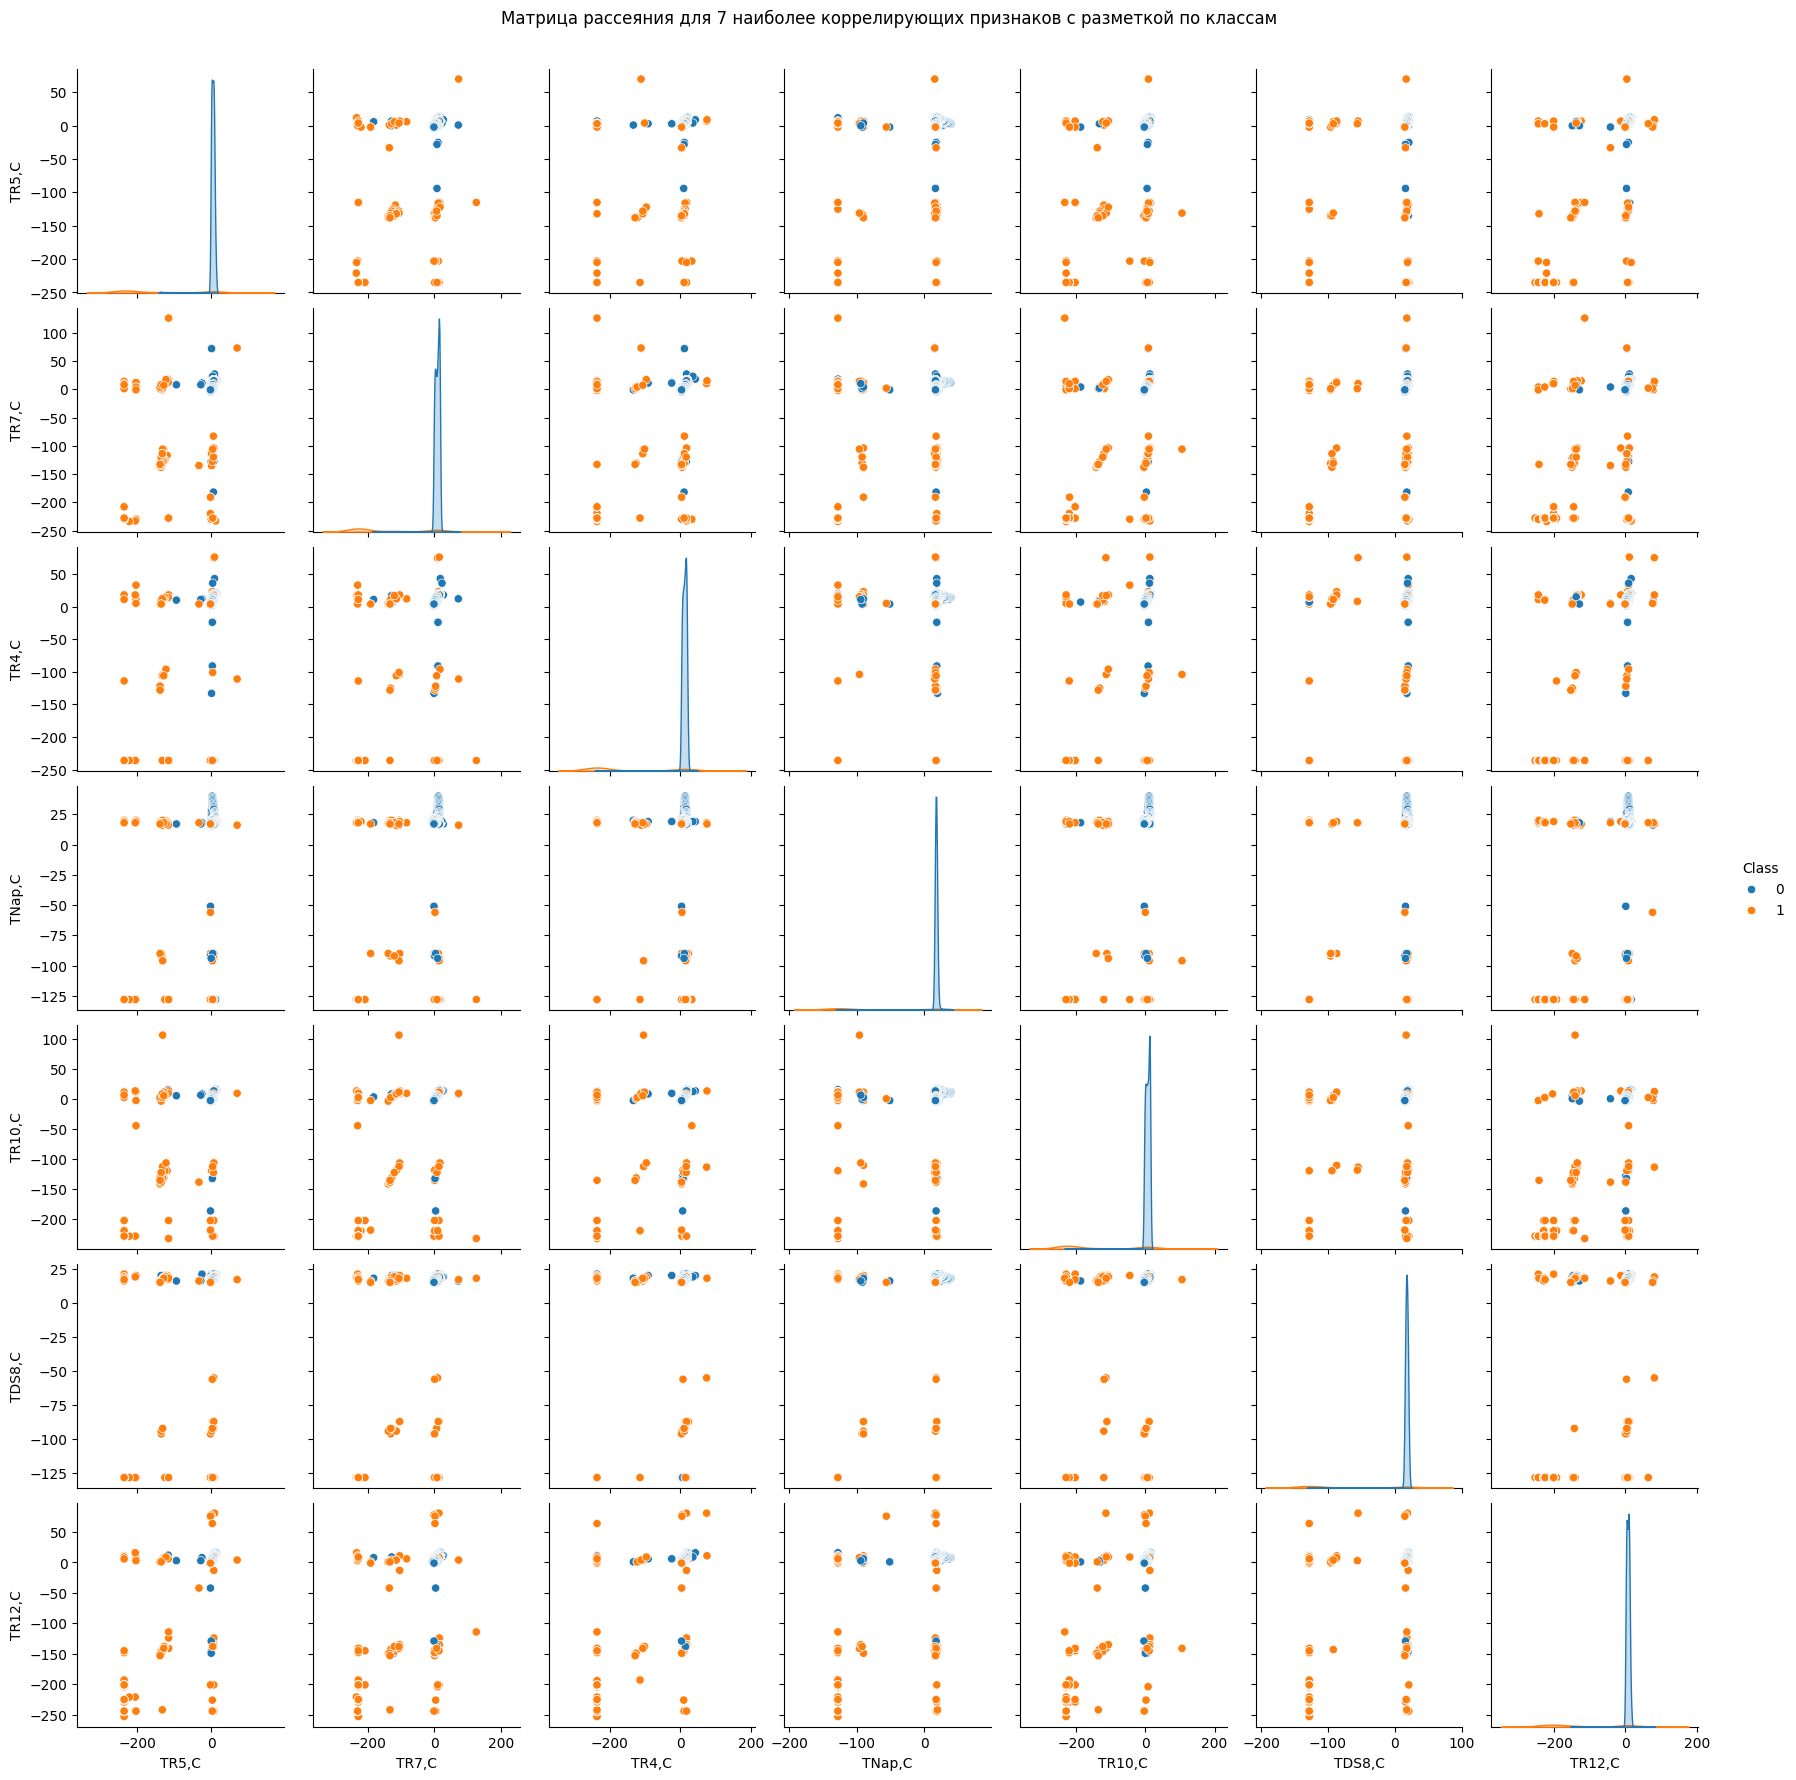

In [ ]:
sns.pairplot(df_top_features, hue='Class', diag_kind='kde')
plt.suptitle('Матрица рассеяния для 7 наиболее коррелирующих признаков с разметкой по классам', y=1.02)
plt.show()

По матрице рассеяния можно наблюдать следующее:

Разделение классов: Для большинства из этих признаков (TR5,C, TR7,C, TR4,C, TNap,C, TR10,C, TDS8,C, TR12,C) наблюдается четкое разделение между двумя классами (0 и 1) вдоль диагональных графиков. Распределение для нештатного функционирования, 1 (оранжевый) имеет тенденцию смещаться в сторону меньших значений по сравнению со штатным, 0 (синий). Это согласуется с нашими предыдущими выводами о том, что эти признаки имеют сильную отрицательную корреляцию с целевым столбцом.

Распределения признаков: Графики KDE по диагонали показывают, что для класса 0 (штатное ф-е) эти признаки, как правило, имеют более высокие значения, в то время как для класса 1 (нештатное ф-е) значения сосредоточены в более низком диапазоне.

Взаимосвязь между признаками: На внедиагональных диаграммах рассеяния мы видим, как пары этих признаков связаны друг с другом. Например, распространенной закономерностью может быть то, что экземпляры класса 1 имеют тенденцию группироваться в областях, где оба признака в паре имеют низкие значения. Это говорит о том, что низкие значения нескольких признаков «TR» и «TDS» являются сильными индикаторами аномального состояния.

Перекрытие: Хотя существует хорошая степень разделения, есть некоторое перекрытие, особенно там, где значения ближе к границам между распределениями. Это указывает на то, что, хотя эти признаки очень информативны, они могут не идеально разделять классы сами по себе, и модели необходимо будет изучить эти границы принятия решений.

В заключение, матрица рассеяния визуально подтверждает высокую прогностическую способность этих 7 признаков, показывая отчетливые закономерности для нормального и аномального классов, в частности, что более низкие значения этих признаков характерны для аномального состояния.

Проведем анализ mutal information


Mutual Information

In [ ]:
X = df_binary.drop('Class', axis=1)
y = df_binary['Class']

mi_scores = mutual_info_classif(X, y, random_state=57)
mi_series = pd.Series(mi_scores, index=X.columns)

mi_series = mi_series.sort_values(ascending=False)

Визуализация MI

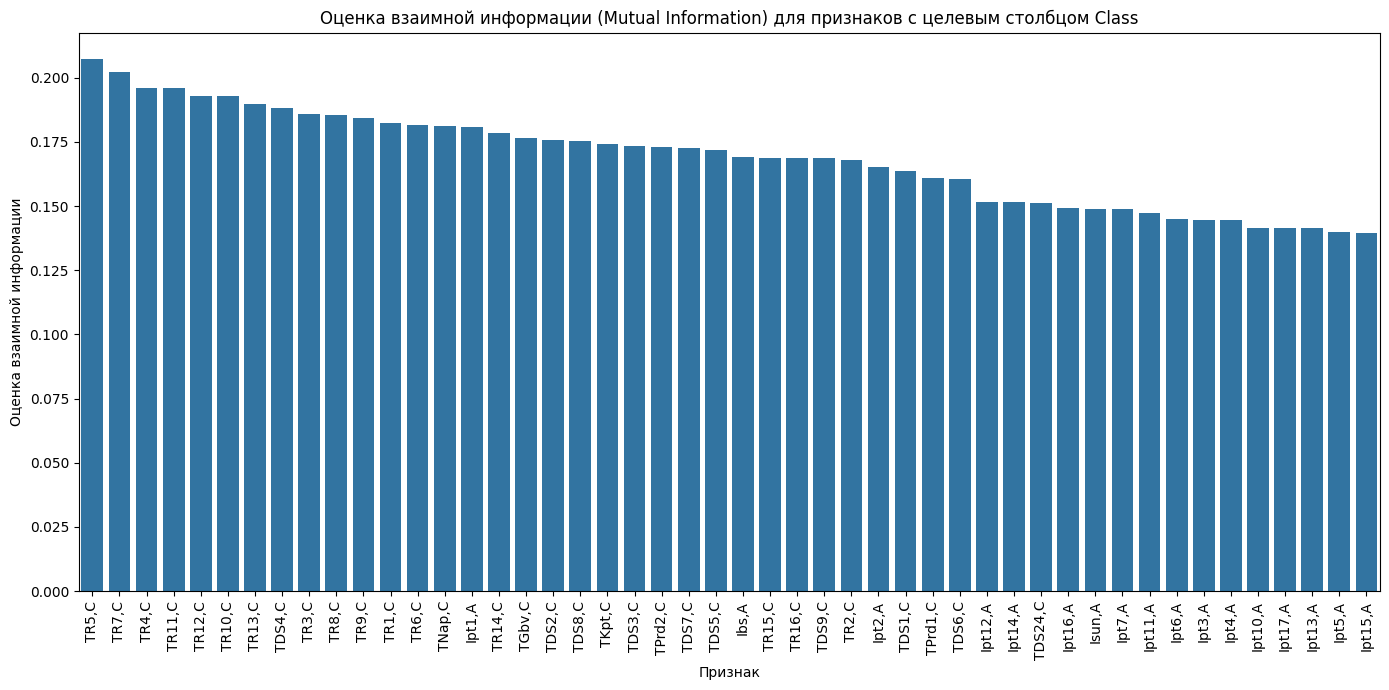

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=mi_series.index, y=mi_series.values)
plt.title('Оценка взаимной информации (Mutual Information) для признаков с целевым столбцом Class')
plt.xlabel('Признак')
plt.ylabel('Оценка взаимной информации')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Анализ взаимной информации (Mutual Information)

Анализ взаимной информации позволяет оценить степень зависимости между каждым признаком и целевым столбцом 'Class'. Высокие значения MI указывают на то, что признак имеет сильную связь с целевой переменной и потенциально является важным для классификации. В отличие от корреляции Пирсона, взаимная информация может улавливать нелинейные зависимости.

На графике выше представлены оценки взаимной информации для всех признаков, отсортированные в порядке убывания. Признаки с более высокими столбцами являются более информативными для предсказания 'Class'.

**Ключевые наблюдения:**

*   Признаки с высокими значениями MI являются наиболее важными для предсказания целевого класса.
*   Эти признаки стоит рассмотреть для включения в модель, так как они несут значимую информацию о 'Class'.
*   Признаки с низкими значениями MI могут быть менее полезными и, возможно, их можно исключить для упрощения модели и уменьшения размерности, если это не приведет к существенной потере производительности.



## Гистограммы

Гистограммы признаков

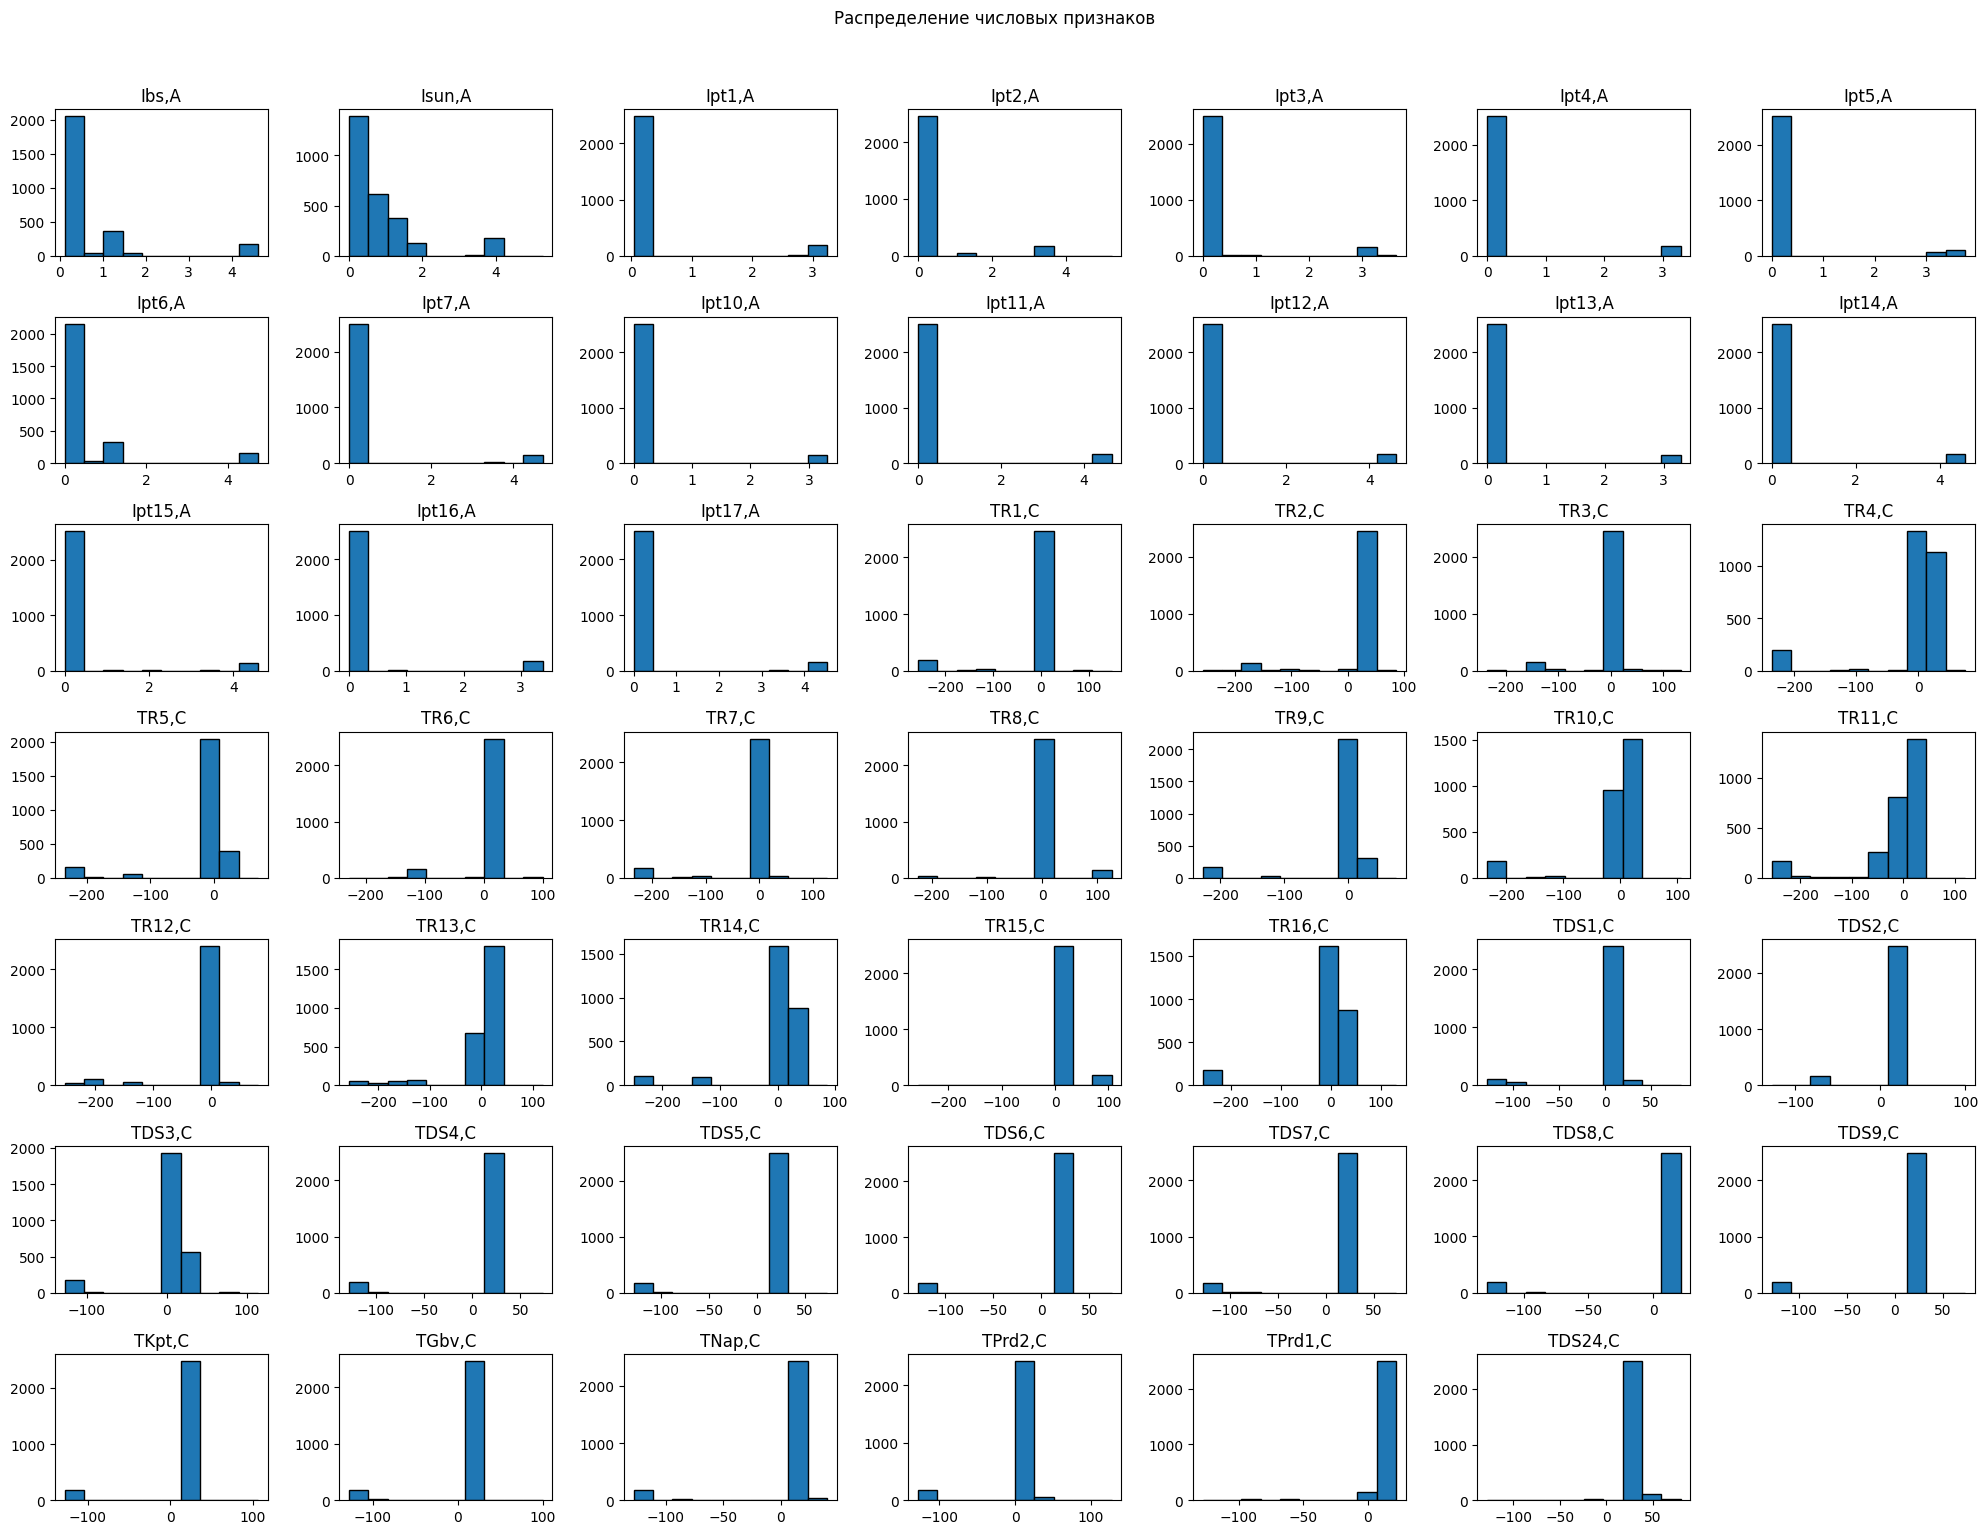

In [ ]:
feature_columns = df_binary.select_dtypes(include=[np.number]).columns.tolist()
feature_columns.remove('Class')
_ = df_binary[feature_columns].hist(
bins=10,
figsize=(20, 15),
grid=False,
edgecolor="black",
)
plt.suptitle("Распределение числовых признаков", y=1.02)
plt.tight_layout()
plt.show()

Гистограммы числовых признаков показывают распределение значений для каждого признака. Анализируя эти гистограммы, можно сделать следующие выводы:

Форма распределения: Большинство признаков имеют несимметричные распределения, часто с длинным хвостом вправо (положительная асимметрия) или влево (отрицательная асимметрия). Например, многие признаки Ipt и Ibs имеют распределения, где большая часть значений сосредоточена вблизи нуля, а затем плавно уменьшается.

Мультимодальные распределения: Некоторые признаки могут иметь несколько пиков, что может указывать на наличие различных подгрупп данных в одном признаке.

Диапазон значений: Гистограммы также демонстрируют диапазон значений для каждого признака. Например, некоторые температурные показатели (TR, TDS) могут иметь достаточно узкий диапазон значений, в то время как другие могут быть более разбросанными.

Выбросы: Некоторые гистограммы могут указывать на наличие возможных выбросов, где очень мало значений находятся далеко от основной массы данных. Это может потребовать дополнительного изучения.


## Обработка


Масштабирование

In [ ]:
X = df_binary.drop('Class', axis=1)
y = df_binary['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled features
df_binary_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# df_binary_scaled теперь содержит только масштабированные признаки, без столбца 'Class'.

print("Первые 5 строк масштабированного датафрейма df_binary_scaled (только признаки):")
display(df_binary_scaled.head())

Первые 5 строк масштабированного датафрейма df_binary_scaled (только признаки):


,"Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A",...,"TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C"
"Ubs,V",,,,,,,,,,,,,,,,,,,,,
14.83,-0.409047,0.166197,-0.262649,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.235870,0.247672,0.111007,-0.014388
14.76,-0.436864,-0.475512,-0.287468,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.235870,0.247672,0.111007,-0.014388
14.83,-0.409047,-0.134604,-0.262649,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.261966,0.247672,0.111007,-0.014388
14.83,-0.436864,-0.234871,-0.287468,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.261966,0.247672,0.111007,-0.014388
14.83,-0.436864,-0.395299,-0.287468,-0.270219,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.311961,0.289684,0.297129,0.266475,0.273173,0.246229,0.261966,0.247672,0.111007,-0.014388


Удалим малоинформативные признаки (те, у которых очень маленькое значение MI)


In [ ]:
low_mi_features = ['TPrd1,C', 'TPrd2,C', 'TR8,C', 'TR15,C']

df_processed = df_binary_scaled.drop(columns=low_mi_features)

print(f"Признаки, удаленные из датафрейма: {low_mi_features}")
print(f"Новый размер датафрейма после удаления признаков: {df_processed.shape}")

display(df_processed.head())

Признаки, удаленные из датафрейма: ['TPrd1,C', 'TPrd2,C', 'TR8,C', 'TR15,C']
Новый размер датафрейма после удаления признаков: (2679, 44)


,"Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A",...,"TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TDS24,C"
"Ubs,V",,,,,,,,,,,,,,,,,,,,,
14.83,-0.409047,0.166197,-0.262649,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.310962,0.299349,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.235870,-0.014388
14.76,-0.436864,-0.475512,-0.287468,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.310962,0.299349,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.235870,-0.014388
14.83,-0.409047,-0.134604,-0.262649,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.310962,0.299349,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.261966,-0.014388
14.83,-0.436864,-0.234871,-0.287468,-0.295453,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.310962,0.299349,0.311961,0.261748,0.270952,0.266475,0.273173,0.246229,0.261966,-0.014388
14.83,-0.436864,-0.395299,-0.287468,-0.270219,-0.26271,-0.257642,-0.258449,-0.375804,-0.262231,-0.248189,...,0.310962,0.299349,0.311961,0.289684,0.297129,0.266475,0.273173,0.246229,0.261966,-0.014388


## Разбиение на выборки

Разобьем датасеты на обучающую, валидационную и тестовую в соотношении 0.6/0.2/0.2


In [ ]:
# разделение для оригинальных данных
X_original = df_binary.drop('Class', axis=1)
y = df_binary['Class']

X_orig_train, X_orig_temp, y_train, y_temp = train_test_split(X_original, y, test_size=0.4, random_state=57, stratify=y)
X_orig_test, X_orig_val, y_test, y_val = train_test_split(X_orig_temp, y_temp, test_size=(0.5), random_state=57, stratify=y_temp)

print(f"X_orig_train shape: {X_orig_train.shape}, y_train shape: {y_train.shape}")
print(f"X_orig_val shape: {X_orig_val.shape}, y_val shape: {y_val.shape}")
print(f"X_orig_test shape: {X_orig_test.shape}, y_test shape: {y_test.shape}")

# разделение для обработанных данных
X_proc_train, X_proc_temp, _, _ = train_test_split(df_processed, y, test_size=0.4, random_state=57, stratify=y)
X_proc_test, X_proc_val, _, _ = train_test_split(X_proc_temp, y_temp, test_size=(0.5), random_state=57, stratify=y_temp)

print(f"X_proc_train shape: {X_proc_train.shape}")
print(f"X_proc_val shape: {X_proc_val.shape}")
print(f"X_proc_test shape: {X_proc_test.shape}")

X_orig_train shape: (1607, 48), y_train shape: (1607,)
X_orig_val shape: (536, 48), y_val shape: (536,)
X_orig_test shape: (536, 48), y_test shape: (536,)
X_proc_train shape: (1607, 44)
X_proc_val shape: (536, 44)
X_proc_test shape: (536, 44)


Так как Conv1D ожидает 3D-тензор формы (samples, timesteps/steps, channels), а у нас табличные данные (samples, features), преобразуем данные таким образом:
Каждый признак — это шаг последовательности с 1 каналом: (n_samples, n_features, 1) — это логично для телеметрии, где признаки могут иметь смысловую последовательность.


In [ ]:
np.random.seed(57)
tf.random.set_seed(57)

Подготовка данных для CNN

In [ ]:
def prepare_data_for_cnn(X, y=None, timesteps_first=True):
    """
    Преобразует табличные данные (n_samples, n_features)
    в последовательные данные для Conv1D (n_samples, timesteps, channels)
    """
    X_array = X.values if hasattr(X, 'values') else X

    if timesteps_first:
        # Каждый признак = шаг с 1 каналом: (n, f, 1)
        X_cnn = np.expand_dims(X_array, axis=-1)
    else:
        # Один шаг с всеми признаками: (n, 1, f)
        X_cnn = np.expand_dims(X_array, axis=1)

    if y is not None:
        y_array = y.values if hasattr(y, 'values') else y
        return X_cnn, y_array
    return X_cnn

# Подготовка данных
X_orig_train_cnn, y_train_arr = prepare_data_for_cnn(X_orig_train, y_train)
X_orig_val_cnn, y_val_arr = prepare_data_for_cnn(X_orig_val, y_val)
X_proc_train_cnn, _ = prepare_data_for_cnn(X_proc_train, y_train)
X_proc_val_cnn, _ = prepare_data_for_cnn(X_proc_val, y_val)

print(f"Оригинал: train {X_orig_train_cnn.shape}, val {X_orig_val_cnn.shape}")
print(f"Обработанный: train {X_proc_train_cnn.shape}, val {X_proc_val_cnn.shape}")

Оригинал: train (1607, 48, 1), val (536, 48, 1)
Обработанный: train (1607, 44, 1), val (536, 44, 1)


## Ансамбль

Класс CNNClassifier

In [ ]:
class CNNClassifier(BaseEstimator, ClassifierMixin):
    """
    Wrapper для CNN-модели Keras (Conv1D), совместимый с sklearn API.
    Нужен для использования в BaggingClassifier и для генетического алгоритма.
    """

    def __init__(self,
                 input_shape=None,
                 n_conv_layers=2,
                 n_filters=64,
                 kernel_size=3,
                 n_dense_layers=2,
                 dense_units=32,
                 dropout_rate=0.3,
                 l2_reg=0.001,
                 activation='relu',
                 learning_rate=0.001,
                 epochs=50,
                 batch_size=32,
                 verbose=0,
                 random_state=None):
        """
        Параметры модели — все нужны для генетического алгоритма.
        """
        self.input_shape = input_shape
        self.n_conv_layers = n_conv_layers
        self.n_filters = n_filters
        self.kernel_size = kernel_size
        self.n_dense_layers = n_dense_layers
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.l2_reg = l2_reg
        self.activation = activation
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

        self.model_ = None
        self.history_ = None
        self.class_weight_ = None

    def _build_model(self, input_shape):
        """Создаёт и компилирует CNN-модель"""
        inputs = layers.Input(shape=input_shape)
        x = inputs

        # Свёрточные слои Conv1D
        for i in range(self.n_conv_layers):
            x = layers.Conv1D(
                filters=self.n_filters,
                kernel_size=min(self.kernel_size, x.shape[1]),  # не больше длины входа
                padding='same',
                activation=self.activation,
                kernel_regularizer=regularizers.l2(self.l2_reg) if self.l2_reg > 0 else None
            )(x)
            x = layers.MaxPooling1D(pool_size=2, padding='same')(x)
            x = layers.Dropout(self.dropout_rate)(x)

        # Преобразование в вектор (Flatten) перед полносвязными слоями
        x = layers.GlobalAveragePooling1D()(x)

        # Полносвязные слои
        for _ in range(self.n_dense_layers):
            x = layers.Dense(
                self.dense_units,
                activation=self.activation,
                kernel_regularizer=regularizers.l2(self.l2_reg) if self.l2_reg > 0 else None
            )(x)
            x = layers.Dropout(self.dropout_rate)(x)

        # Выходной слой
        outputs = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inputs, outputs)

        # Компиляция
        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    def fit(self, X, y, **fit_kwargs):
        """Обучение модели"""
        if self.random_state is not None:
            np.random.seed(self.random_state)
            tf.random.set_seed(self.random_state)

        # Веса классов для борьбы с дисбалансом (2356:323)
        cw = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        self.class_weight_ = {i: w for i, w in enumerate(cw)}

        # Построение модели
        input_shape = X.shape[1:]
        self.model_ = self._build_model(input_shape)

        # Callbacks — ранняя остановка и уменьшение learning rate
        cb = [
            callbacks.EarlyStopping(
                monitor='val_loss', patience=15, mode='min',
                restore_best_weights=True, verbose=0
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=8,
                min_lr=1e-7, verbose=0
            )
        ]

        # Обучение
        self.history_ = self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            class_weight=self.class_weight_,
            callbacks=cb,
            validation_data=(fit_kwargs.get('X_val'), fit_kwargs.get('y_val'))
                           if 'X_val' in fit_kwargs else None
        )

        return self

    def predict_proba(self, X):
        """Вероятности класса 1"""
        proba = self.model_.predict(X, verbose=0).ravel()
        return np.column_stack([1 - proba, proba])

    def predict(self, X, threshold=0.5):
        """Бинарные предсказания"""
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

    def get_params(self, deep=True):
        """
        Нужен для генетического алгоритма — чтобы можно было
        программно читать и менять гиперпараметры особи.
        """
        return {
            'n_conv_layers': self.n_conv_layers,
            'n_filters': self.n_filters,
            'kernel_size': self.kernel_size,
            'n_dense_layers': self.n_dense_layers,
            'dense_units': self.dense_units,
            'dropout_rate': self.dropout_rate,
            'l2_reg': self.l2_reg,
            'activation': self.activation,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        """
        Нужен для генетического алгоритма — чтобы можно было
        применять мутации и кроссовер к гиперпараметрам.
        """
        for key, value in params.items():
            if hasattr(self, key):
                setattr(self, key, value)
        return self

Функция обучения ансамбля Bagging

In [ ]:
def train_cnn_bagging_manual(X_train_cnn, y_train, X_val_cnn, y_val,
                              n_estimators=3, log_dir=None, base_random_state=57,
                              **model_params):
    """
    Ручная реализация Bagging-ансамбля из CNN-классификаторов.

    Parameters:
    - base_random_state: базовый seed, от него будут генерироваться семена для каждой модели
    - **model_params: параметры модели, КРОМЕ random_state (он управляется внутри)

    Returns: dict with ensemble, list of logs
    """
    # Удаляем random_state из model_params, если есть — будем управлять им сами
    model_params.pop('random_state', None)

    print(f"Обучение ансамбля из {n_estimators} моделей...")

    models = []
    logs = []

    for i in range(n_estimators):
        print(f"  └─ Модель {i+1}/{n_estimators}...", end=' ')

        # Бутстрап-выборка (с возвратом)
        rng = np.random.RandomState(base_random_state + i)
        indices = rng.choice(len(X_train_cnn), size=len(X_train_cnn), replace=True)
        X_boot = X_train_cnn[indices]
        y_boot = y_train[indices]

        # Создаём модель — random_state задаём явно для воспроизводимости
        clf = CNNClassifier(
            input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2]),
            random_state=base_random_state + i,  # уникальный seed для каждой модели
            **model_params  # остальные параметры из словаря
        )

        # Обучение с валидацией
        clf.fit(X_boot, y_boot, X_val=X_val_cnn, y_val=y_val)

        models.append(clf)

        # Логирование
        if clf.history_ is not None:
            hist = clf.history_.history
            best_val_loss = min(hist.get('val_loss', [np.inf]))
            logs.append({
                'model_id': i,
                'best_val_loss': float(best_val_loss),
                'epochs_trained': len(hist.get('loss', [])),
                'train_samples': len(X_boot),
                'unique_samples': len(np.unique(indices)),
                'random_state': base_random_state + i
            })
            print(f"✓ val_loss={best_val_loss:.4f}")
        else:
            print("✗ ошибка обучения")
            logs.append({'model_id': i, 'error': 'training_failed'})

    # Функции для предсказаний ансамбля
    def predict_proba_ensemble(X):
        probas = [m.predict_proba(X)[:, 1] for m in models]
        return np.mean(probas, axis=0)

    def predict_ensemble(X, threshold=0.5):
        proba = predict_proba_ensemble(X)
        return (proba >= threshold).astype(int)

    # Упаковываем ансамбль
    ensemble = {
        'models': models,
        'n_estimators': n_estimators,
        'predict_proba': predict_proba_ensemble,
        'predict': predict_ensemble
    }

    # Сохранение логов
    if log_dir and logs:
        os.makedirs(log_dir, exist_ok=True)
        with open(f"{log_dir}/bagging_log.json", 'w') as f:
            json.dump(logs, f, indent=2, default=str)
        print(f"Логи сохранены в {log_dir}")

    return ensemble, logs

Функция оценки ансамбля

In [ ]:
def evaluate_ensemble(ensemble, X_cnn, y_true, threshold=0.5):
    """
    Оценка ансамбля
    """
    # Получаем предсказания
    if isinstance(ensemble, dict) and 'predict_proba' in ensemble:
        # Наш ручной ансамбль
        y_proba = ensemble['predict_proba'](X_cnn)
        y_pred = ensemble['predict'](X_cnn, threshold)
    else:
        # sklearn.ensemble.BaggingClassifier
        y_proba = ensemble.predict_proba(X_cnn)[:, 1]
        y_pred = ensemble.predict(X_cnn)

    # Метрики
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1-score': report['1']['f1-score'],
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

    return metrics, report, y_pred, y_proba

## Обучение


Обучение ансамбля на обоих наборах данных

ОБУЧЕНИЕ: ОРИГИНАЛЬНЫЙ НАБОР (48 признаков)
Обучение ансамбля из 3 моделей...
  └─ Модель 1/3... ✓ val_loss=0.0481
  └─ Модель 2/3... ✓ val_loss=0.0528
  └─ Модель 3/3... ✓ val_loss=0.0581
Логи сохранены в /content/cnn_bagging_logs/original

Метрики на валидации (оригинальный набор):
  Accuracy: 0.9851
  Precision: 0.9254
  Recall: 0.9538
  F1-Score: 0.9394
  Balanced Accuracy: 0.9716
  Roc Auc: 0.9911

ОБУЧЕНИЕ: ОБРАБОТАННЫЙ НАБОР (44 признака)
Обучение ансамбля из 3 моделей...
  └─ Модель 1/3... ✓ val_loss=0.0355
  └─ Модель 2/3... ✓ val_loss=0.0352
  └─ Модель 3/3... ✓ val_loss=0.0342
Логи сохранены в /content/cnn_bagging_logs/processed

Метрики на валидации (обработанный набор):
  Accuracy: 0.9888
  Precision: 0.9538
  Recall: 0.9538
  F1-Score: 0.9538
  Balanced Accuracy: 0.9737
  Roc Auc: 0.9986

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
           Metric  Original (48 feat)  Processed (44 feat)
         Accuracy            0.985075             0.988806
        Precision            0.925373         

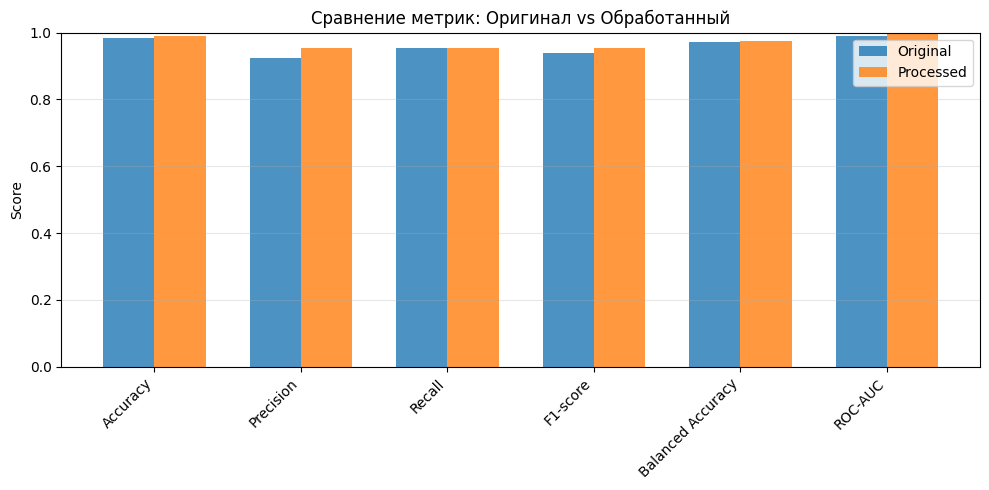

In [ ]:
MODEL_PARAMS = {
    'n_conv_layers': 1,
    'n_filters': 32,
    'kernel_size': 5,
    'n_dense_layers': 1,
    'dense_units': 16,
    'dropout_rate': 0.2,
    'l2_reg': 0.0,
    'activation': 'relu',
    'learning_rate': 0.005,
    'epochs': 50,
    'batch_size': 32
}

LOG_DIR = "/content/cnn_bagging_logs"
os.makedirs(LOG_DIR, exist_ok=True)

# ========== ОРИГИНАЛЬНЫЙ НАБОР ==========
print("="*60)
print("ОБУЧЕНИЕ: ОРИГИНАЛЬНЫЙ НАБОР (48 признаков)")
print("="*60)

ensemble_orig, logs_orig = train_cnn_bagging_manual(
    X_orig_train_cnn, y_train_arr,
    X_orig_val_cnn, y_val_arr,
    n_estimators=3,
    base_random_state=57,  # базовый seed для ансамбля
    log_dir=f"{LOG_DIR}/original",
    **MODEL_PARAMS
)

metrics_orig, _, _, _ = evaluate_ensemble(ensemble_orig, X_orig_val_cnn, y_val_arr)
print("\nМетрики на валидации (оригинальный набор):")
for k in ['accuracy', 'precision', 'recall', 'f1-score', 'balanced_accuracy', 'roc_auc']:
    label = k.replace('_', ' ').title()
    print(f"  {label}: {metrics_orig[k]:.4f}")

# ========== ОБРАБОТАННЫЙ НАБОР ==========
print("\n" + "="*60)
print("ОБУЧЕНИЕ: ОБРАБОТАННЫЙ НАБОР (44 признака)")
print("="*60)

ensemble_proc, logs_proc = train_cnn_bagging_manual(
    X_proc_train_cnn, y_train_arr,
    X_proc_val_cnn, y_val_arr,
    n_estimators=3,
    base_random_state=57,
    log_dir=f"{LOG_DIR}/processed",
    **MODEL_PARAMS
)

metrics_proc, _, _, _ = evaluate_ensemble(ensemble_proc, X_proc_val_cnn, y_val_arr)
print("\nМетрики на валидации (обработанный набор):")
for k in ['accuracy', 'precision', 'recall', 'f1-score', 'balanced_accuracy', 'roc_auc']:
    label = k.replace('_', ' ').title()
    print(f"  {label}: {metrics_proc[k]:.4f}")

# ========== СРАВНЕНИЕ ==========
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

comp_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Balanced Accuracy', 'ROC-AUC'],
    'Original (48 feat)': [metrics_orig[k] for k in ['accuracy','precision','recall','f1-score','balanced_accuracy','roc_auc']],
    'Processed (44 feat)': [metrics_proc[k] for k in ['accuracy','precision','recall','f1-score','balanced_accuracy','roc_auc']]
})
print(comp_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 5))
x = np.arange(len(comp_df))
width = 0.35
plt.bar(x - width/2, comp_df['Original (48 feat)'], width, label='Original', alpha=0.8)
plt.bar(x + width/2, comp_df['Processed (44 feat)'], width, label='Processed', alpha=0.8)
plt.xticks(x, comp_df['Metric'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Сравнение метрик: Оригинал vs Обработанный')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Анализ результатов по классам

Детальная оценка

ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА

Classification Report — Original (48 feat)
               precision    recall  f1-score   support

  Штатное (0)       0.99      0.99      0.99       471
Нештатное (1)       0.93      0.95      0.94        65

     accuracy                           0.99       536
    macro avg       0.96      0.97      0.97       536
 weighted avg       0.99      0.99      0.99       536



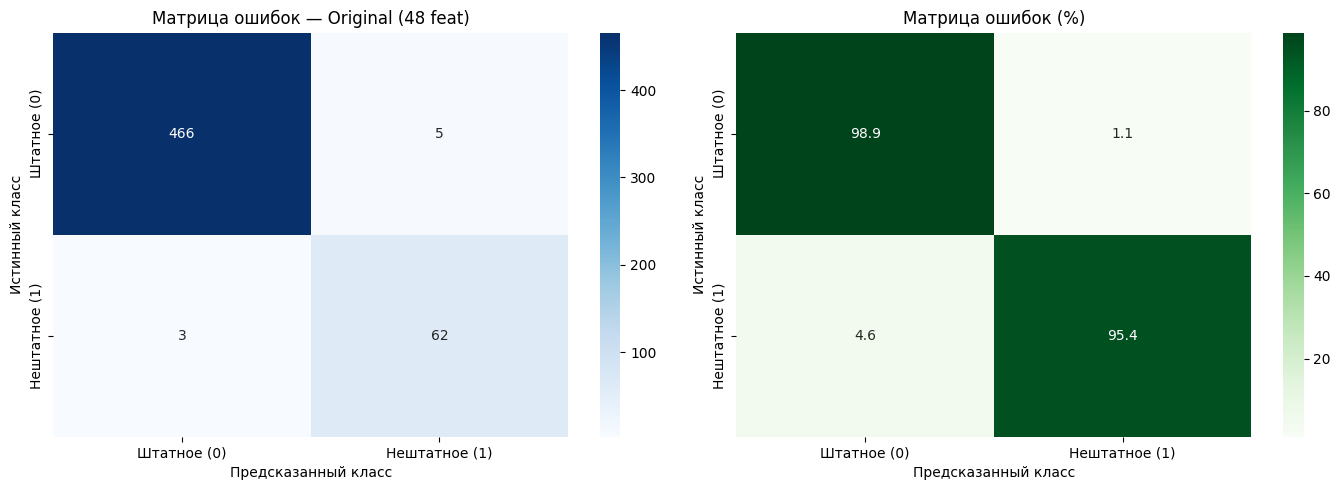

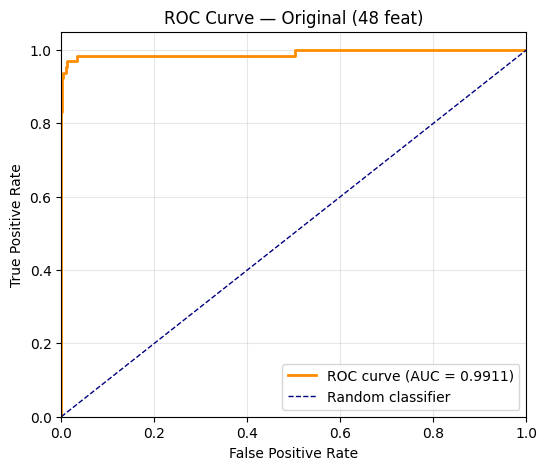


Анализ ошибок — Original (48 feat)
------------------------------------------------------------
False Negative (пропущено аномалий): 3 из 65
   → Доля пропущенных: 4.62%
False Positive (ложные тревоги): 5 из 471
   → Доля ложных: 1.06%

Classification Report — Processed (44 feat)
               precision    recall  f1-score   support

  Штатное (0)       0.99      0.99      0.99       471
Нештатное (1)       0.95      0.95      0.95        65

     accuracy                           0.99       536
    macro avg       0.97      0.97      0.97       536
 weighted avg       0.99      0.99      0.99       536



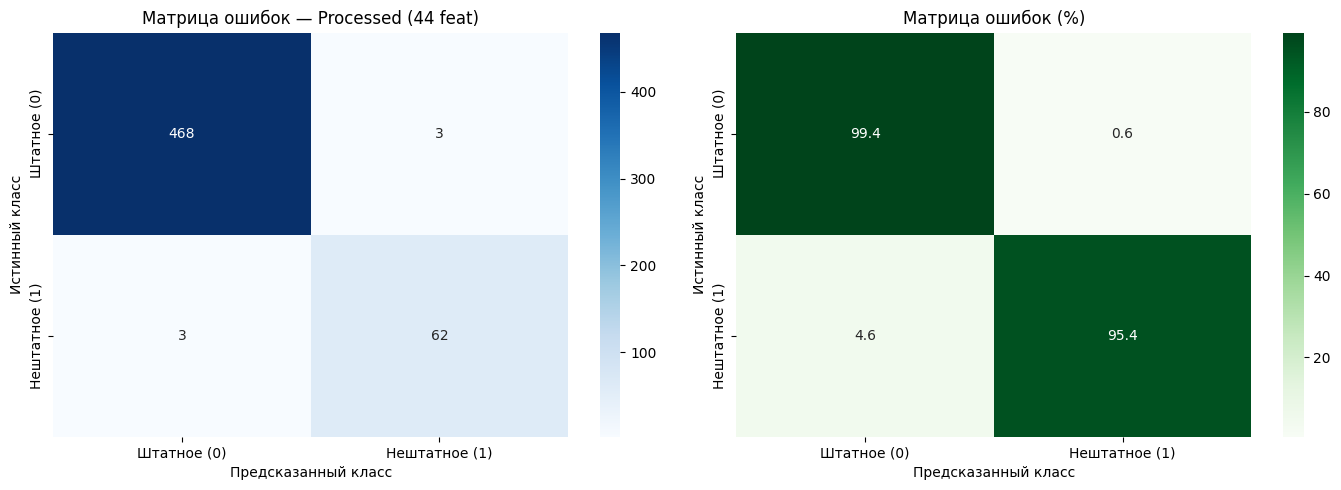

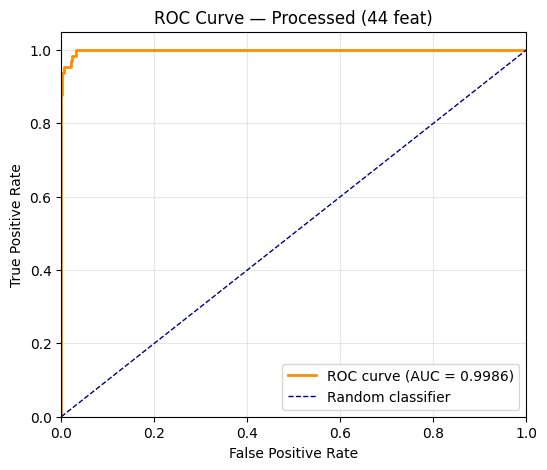


Анализ ошибок — Processed (44 feat)
------------------------------------------------------------
False Negative (пропущено аномалий): 3 из 65
   → Доля пропущенных: 4.62%
False Positive (ложные тревоги): 3 из 471
   → Доля ложных: 0.64%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_detailed_evaluation(ensemble, X_cnn, y_true, dataset_name, threshold=0.5):
    """
    Детальная оценка: классификационный отчёт + матрица ошибок + кривая ROC
    """
    from sklearn.metrics import roc_curve, auc

    # Предсказания
    y_proba = ensemble['predict_proba'](X_cnn) if isinstance(ensemble, dict) else ensemble.predict_proba(X_cnn)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # === 1. Classification Report по классам ===
    print(f"\nClassification Report — {dataset_name}")
    print("="*60)
    report = classification_report(y_true, y_pred, target_names=['Штатное (0)', 'Нештатное (1)'],
                                   output_dict=False, zero_division=0)
    print(report)

    # === 2. Confusion Matrix ===
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Матрица ошибок с числами
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Штатное (0)', 'Нештатное (1)'],
                yticklabels=['Штатное (0)', 'Нештатное (1)'],
                ax=axes[0])
    axes[0].set_title(f'Матрица ошибок — {dataset_name}')
    axes[0].set_ylabel('Истинный класс')
    axes[0].set_xlabel('Предсказанный класс')

    # Матрица ошибок в процентах
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
                xticklabels=['Штатное (0)', 'Нештатное (1)'],
                yticklabels=['Штатное (0)', 'Нештатное (1)'],
                ax=axes[1])
    axes[1].set_title('Матрица ошибок (%)')
    axes[1].set_ylabel('Истинный класс')
    axes[1].set_xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

    # === 3. ROC Curve ===
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {dataset_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    # === 4. Анализ ошибок ===
    print(f"\nАнализ ошибок — {dataset_name}")
    print("-"*60)

    # False Negative (пропущенные аномалии)
    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    print(f"False Negative (пропущено аномалий): {len(fn_idx)} из {np.sum(y_true==1)}")
    if len(fn_idx) > 0:
        print(f"   → Доля пропущенных: {len(fn_idx)/np.sum(y_true==1)*100:.2f}%")

    # False Positive (ложные тревоги)
    fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
    print(f"False Positive (ложные тревоги): {len(fp_idx)} из {np.sum(y_true==0)}")
    if len(fp_idx) > 0:
        print(f"   → Доля ложных: {len(fp_idx)/np.sum(y_true==0)*100:.2f}%")

    return {'cm': cm, 'report': report, 'roc_auc': roc_auc_val, 'fn_count': len(fn_idx), 'fp_count': len(fp_idx)}

# === Запуск для обоих наборов ===
print("ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА")
print("="*60)

results_orig = plot_detailed_evaluation(ensemble_orig, X_orig_val_cnn, y_val_arr, "Original (48 feat)")
results_proc = plot_detailed_evaluation(ensemble_proc, X_proc_val_cnn, y_val_arr, "Processed (44 feat)")

False Negative (пропущенные аномалии):
   
   Исходный набор: 3 из 65 (4.62%)

   Обработанный набор: 3 из 65 (4.62%)

 Это очень важный показатель для космического аппарата, лучше иметь больше ложных тревог, чем пропустить реальный отказ.

False Positive (ложные тревоги):

   Исходный набор: 5 из 471 (1.06%)

   Обработанный набор: 3 из 471 (0.64%)


Вывод:

Оба набора данных показали высокое и практически равное качество детекции аномалий.

Количество пропущенных аномалий (False Negative) одинаково для обоих наборов: 3 из 65 (4.62%). Это подтверждает, что удалённые 4 признака действительно не несли значимой информации для классификатора.

Обработанный набор (44 признака) выигрывает по всем остальным метрикам: Precision (0.95 vs 0.93), F1-score (0.954 vs 0.939), количество ложных тревог (FP: 3 vs 5) и ROC-AUC (0.9986 vs 0.9911). Это закономерno: удаление коррелированных и малоинформативных признаков снижает «шум», что улучшает обобщающую способность модели.

Для дальнейшей работы выберем обработанный набор данных (44 признака), так как при равном числе пропущенных аномалий он обеспечивает более высокую точность и меньше ложных тревог.

## Подбор гиперпараметров генетическим алгоритмом (DEAP)

Установка DEAP

In [ ]:
!pip install deap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 6.3 MB/s eta 0:00:00


In [ ]:
from deap import base, creator, tools, algorithms

Подготовка тестовых данных

In [ ]:
X_proc_test_cnn, y_test_arr = prepare_data_for_cnn(X_proc_test, y_test)

print(f"Тестовая выборка готова:")
print(f"  Processed: {X_proc_test_cnn.shape}, классы: {np.bincount(y_test_arr)}")

Тестовая выборка готова:
  Processed: (536, 44, 1), классы: [472  64]


CNNClassifier (версия для ГА)

In [ ]:
class CNNClassifier(BaseEstimator, ClassifierMixin):
    """
    Wrapper для CNN-модели, оптимизированный для ГА.
    """

    def __init__(self,
                 input_shape=None,
                 n_conv_layers=2,
                 n_filters=64,
                 kernel_size=3,
                 n_dense_layers=2,
                 dense_units=32,
                 dropout_rate=0.3,
                 l2_reg=0.001,
                 activation='relu',
                 learning_rate=0.001,
                 epochs=30,  # Уменьшено для скорости ГА
                 batch_size=32,
                 verbose=0,
                 random_state=None):

        self.input_shape = input_shape
        self.n_conv_layers = n_conv_layers
        self.n_filters = n_filters
        self.kernel_size = kernel_size
        self.n_dense_layers = n_dense_layers
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.l2_reg = l2_reg
        self.activation = activation
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

        self.model_ = None
        self.history_ = None

    def _build_model(self, input_shape):
        inputs = layers.Input(shape=input_shape)
        x = inputs

        for i in range(self.n_conv_layers):
            x = layers.Conv1D(
                filters=self.n_filters,
                kernel_size=min(self.kernel_size, x.shape[1]),
                padding='same',
                activation=self.activation,
                kernel_regularizer=regularizers.l2(self.l2_reg) if self.l2_reg > 0 else None
            )(x)
            x = layers.MaxPooling1D(pool_size=2, padding='same')(x)
            x = layers.Dropout(self.dropout_rate)(x)

        x = layers.GlobalAveragePooling1D()(x)

        for _ in range(self.n_dense_layers):
            x = layers.Dense(
                self.dense_units,
                activation=self.activation,
                kernel_regularizer=regularizers.l2(self.l2_reg) if self.l2_reg > 0 else None
            )(x)
            x = layers.Dropout(self.dropout_rate)(x)

        outputs = layers.Dense(1, activation='sigmoid')(x)
        model = Model(inputs, outputs)

        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    def fit(self, X, y, X_val=None, y_val=None):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            tf.random.set_seed(self.random_state)

        cw = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        class_weight_dict = {i: w for i, w in enumerate(cw)}

        input_shape = X.shape[1:]
        self.model_ = self._build_model(input_shape)

        cb = [
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, mode='min',
                restore_best_weights=True, verbose=0
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5,
                min_lr=1e-7, verbose=0
            )
        ]

        val_data = (X_val, y_val) if X_val is not None else None

        self.history_ = self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            class_weight=class_weight_dict,
            callbacks=cb,
            validation_data=val_data
        )

        return self

    def predict_proba(self, X):
        proba = self.model_.predict(X, verbose=0).ravel()
        return np.column_stack([1 - proba, proba])

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

    def get_params(self, deep=True):
        return {
            'n_conv_layers': self.n_conv_layers,
            'n_filters': self.n_filters,
            'kernel_size': self.kernel_size,
            'n_dense_layers': self.n_dense_layers,
            'dense_units': self.dense_units,
            'dropout_rate': self.dropout_rate,
            'l2_reg': self.l2_reg,
            'activation': self.activation,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for key, value in params.items():
            if hasattr(self, key):
                setattr(self, key, value)
        return self

Пространство поиска гиперпараметров

In [ ]:
# Пространство поиска гиперпараметров
PARAM_SPACE = {
    'n_conv_layers': {'type': 'int', 'min': 1, 'max': 4},
    'n_filters': {'type': 'int', 'min': 32, 'max': 128, 'step': 16},
    'kernel_size': {'type': 'int', 'min': 2, 'max': 7},
    'n_dense_layers': {'type': 'int', 'min': 1, 'max': 3},
    'dense_units': {'type': 'int', 'min': 16, 'max': 64, 'step': 8},
    'dropout_rate': {'type': 'float', 'min': 0.1, 'max': 0.6},
    'l2_reg': {'type': 'float', 'min': 0.0, 'max': 0.01},
    'learning_rate': {'type': 'float_log', 'min': 1e-5, 'max': 1e-2},
}

# Параметры эволюции
GA_CONFIG = {
    'population_size': 10,
    'n_generations': 5,
    'crossover_prob': 0.7,
    'mutation_prob': 0.3,
    'elitism_count': 2,
    'seed': 57
}

print("Пространство гиперпараметров:")
for param, config in PARAM_SPACE.items():
    print(f"  {param}: {config}")

print(f"\nКонфигурация ГА:")
for k, v in GA_CONFIG.items():
    print(f"  {k}: {v}")

Пространство гиперпараметров:
  n_conv_layers: {'type': 'int', 'min': 1, 'max': 4}
  n_filters: {'type': 'int', 'min': 32, 'max': 128, 'step': 16}
  kernel_size: {'type': 'int', 'min': 2, 'max': 7}
  n_dense_layers: {'type': 'int', 'min': 1, 'max': 3}
  dense_units: {'type': 'int', 'min': 16, 'max': 64, 'step': 8}
  dropout_rate: {'type': 'float', 'min': 0.1, 'max': 0.6}
  l2_reg: {'type': 'float', 'min': 0.0, 'max': 0.01}
  learning_rate: {'type': 'float_log', 'min': 1e-05, 'max': 0.01}

Конфигурация ГА:
  population_size: 10
  n_generations: 5
  crossover_prob: 0.7
  mutation_prob: 0.3
  elitism_count: 2
  seed: 57


Фитнес-функция

In [ ]:
# Глобальный словарь для хранения деталей оценки
GA_EVALUATION_DETAILS = {}
EVAL_COUNTER = 0

def evaluate_individual(individual, X_train, y_train, X_val, y_val, input_shape, verbose=0):
    """
    Фитнес-функция для DEAP.
    Возвращает кортеж с фитнесом.
    Детали сохраняем в глобальный словарь GA_EVALUATION_DETAILS.
    """
    global EVAL_COUNTER

    # Декодирование индивидуума в параметры
    params = {
        'n_conv_layers': int(individual[0]),
        'n_filters': int(individual[1]),
        'kernel_size': int(individual[2]),
        'n_dense_layers': int(individual[3]),
        'dense_units': int(individual[4]),
        'dropout_rate': float(individual[5]),
        'l2_reg': float(individual[6]),
        'learning_rate': float(individual[7]),
    }

    try:
        # Создание и обучение модели
        clf = CNNClassifier(
            input_shape=input_shape,
            epochs=30,
            batch_size=32,
            verbose=verbose,
            random_state=57,
            **params
        )

        clf.fit(X_train, y_train, X_val=X_val, y_val=y_val)

        # Оценка на валидации
        y_pred = clf.predict(X_val)
        y_proba = clf.predict_proba(X_val)[:, 1]

        bal_acc = balanced_accuracy_score(y_val, y_pred)
        roc_auc = roc_auc_score(y_val, y_proba)

        # Комбинированный фитнес
        fitness_score = bal_acc * 0.7 + roc_auc * 0.3

        # Сохраняем детали в глобальный словарь
        EVAL_COUNTER += 1
        GA_EVALUATION_DETAILS[EVAL_COUNTER] = {
            'bal_acc': bal_acc,
            'roc_auc': roc_auc,
            'fitness': fitness_score,
            'params': params.copy()
        }

        # Очистка памяти
        keras.backend.clear_session()

        # возвращаем кортеж с фитнесом
        return (fitness_score,)

    except Exception as e:
        print(f"Ошибка оценки особи: {e}")
        keras.backend.clear_session()

        EVAL_COUNTER += 1
        GA_EVALUATION_DETAILS[EVAL_COUNTER] = {
            'bal_acc': 0.0,
            'roc_auc': 0.0,
            'fitness': 0.0,
            'params': params.copy(),
            'error': str(e)
        }

        # Возвращаем худший фитнес
        return (0.0,)

Регистрация DEAP

In [ ]:
# Очистка перед созданием (на случай повторного запуска)
try:
    del creator.FitnessMax
    del creator.Individual
except AttributeError:
    pass

# Регистрация типов для DEAP
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Максимизация
creator.create("Individual", list, fitness=creator.FitnessMax)

# Фабрика особей и популяции
toolbox = base.Toolbox()

# Гены (атрибуты индивидуума)
toolbox.register("attr_n_conv_layers", random.randint,
                 PARAM_SPACE['n_conv_layers']['min'],
                 PARAM_SPACE['n_conv_layers']['max'])

toolbox.register("attr_n_filters", lambda: random.randint(
                 PARAM_SPACE['n_filters']['min'],
                 PARAM_SPACE['n_filters']['max']) //
                 PARAM_SPACE['n_filters']['step'] *
                 PARAM_SPACE['n_filters']['step'])

toolbox.register("attr_kernel_size", random.randint,
                 PARAM_SPACE['kernel_size']['min'],
                 PARAM_SPACE['kernel_size']['max'])

toolbox.register("attr_n_dense_layers", random.randint,
                 PARAM_SPACE['n_dense_layers']['min'],
                 PARAM_SPACE['n_dense_layers']['max'])

toolbox.register("attr_dense_units", lambda: random.randint(
                 PARAM_SPACE['dense_units']['min'],
                 PARAM_SPACE['dense_units']['max']) //
                 PARAM_SPACE['dense_units']['step'] *
                 PARAM_SPACE['dense_units']['step'])

toolbox.register("attr_dropout_rate", random.uniform,
                 PARAM_SPACE['dropout_rate']['min'],
                 PARAM_SPACE['dropout_rate']['max'])

toolbox.register("attr_l2_reg", random.uniform,
                 PARAM_SPACE['l2_reg']['min'],
                 PARAM_SPACE['l2_reg']['max'])

toolbox.register("attr_learning_rate", lambda: 10 ** random.uniform(
                 np.log10(PARAM_SPACE['learning_rate']['min']),
                 np.log10(PARAM_SPACE['learning_rate']['max'])))

# Создание индивидуума и популяции
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_n_conv_layers,
                  toolbox.attr_n_filters,
                  toolbox.attr_kernel_size,
                  toolbox.attr_n_dense_layers,
                  toolbox.attr_dense_units,
                  toolbox.attr_dropout_rate,
                  toolbox.attr_l2_reg,
                  toolbox.attr_learning_rate),
                 n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Операторы эволюции
toolbox.register("evaluate", lambda ind: evaluate_individual(
    ind, X_proc_train_cnn, y_train_arr, X_proc_val_cnn, y_val_arr,
    (X_proc_train_cnn.shape[1], X_proc_train_cnn.shape[2]), verbose=0
))

toolbox.register("mate", tools.cxTwoPoint)

def custom_mutation(individual):
    """Мутация с учётом типов параметров"""
    for i, gene in enumerate(individual):
        if random.random() < 0.5:
            if i == 0:  # n_conv_layers
                individual[i] = random.randint(
                    PARAM_SPACE['n_conv_layers']['min'],
                    PARAM_SPACE['n_conv_layers']['max'])
            elif i == 1:  # n_filters
                individual[i] = random.randint(
                    PARAM_SPACE['n_filters']['min'],
                    PARAM_SPACE['n_filters']['max']) // 16 * 16
            elif i == 2:  # kernel_size
                individual[i] = random.randint(
                    PARAM_SPACE['kernel_size']['min'],
                    PARAM_SPACE['kernel_size']['max'])
            elif i == 3:  # n_dense_layers
                individual[i] = random.randint(
                    PARAM_SPACE['n_dense_layers']['min'],
                    PARAM_SPACE['n_dense_layers']['max'])
            elif i == 4:  # dense_units
                individual[i] = random.randint(
                    PARAM_SPACE['dense_units']['min'],
                    PARAM_SPACE['dense_units']['max']) // 8 * 8
            elif i == 5:  # dropout_rate
                individual[i] = random.uniform(
                    PARAM_SPACE['dropout_rate']['min'],
                    PARAM_SPACE['dropout_rate']['max'])
            elif i == 6:  # l2_reg
                individual[i] = random.uniform(
                    PARAM_SPACE['l2_reg']['min'],
                    PARAM_SPACE['l2_reg']['max'])
            elif i == 7:  # learning_rate
                individual[i] = 10 ** random.uniform(
                    np.log10(PARAM_SPACE['learning_rate']['min']),
                    np.log10(PARAM_SPACE['learning_rate']['max']))
    return individual,

toolbox.register("mutate", custom_mutation)
toolbox.register("select", tools.selTournament, tournsize=3)

# Сброс счётчика перед запуском
EVAL_COUNTER = 0
GA_EVALUATION_DETAILS = {}

print("Инструменты DEAP зарегистрированы")

Инструменты DEAP зарегистрированы


Запуск ГА

In [ ]:
def run_genetic_algorithm_verbose(toolbox, config, log_dir=None):
    """
    Запуск эволюции с ПОДРОБНЫМ логированием каждой особи.
    """
    pop = toolbox.population(n=config['population_size'])
    hof = tools.HallOfFame(config['elitism_count'])
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    evolution_log = {
        'config': config,
        'generations': [],
        'best_individuals': [],
        'all_evaluations': [],
        'start_time': datetime.now().isoformat()
    }

    total_evaluations = config['population_size'] * config['n_generations']
    eval_counter = 0

    print("="*80)
    print("ЗАПУСК ГЕНЕТИЧЕСКОГО АЛГОРИТМА")
    print("="*80)
    print(f"Популяция: {config['population_size']} особей")
    print(f"Поколения: {config['n_generations']}")
    print(f"Всего оценок: ~{total_evaluations}")
    print(f"Элитизм: {config['elitism_count']} лучших")
    print("="*80)

    # Запуск эволюции с ручным контролем для подробного вывода
    for gen in range(config['n_generations']):
        print(f"\n{'='*80}")
        print(f"ПОКОЛЕНИЕ {gen+1}/{config['n_generations']}")
        print(f"{'='*80}")

        # Оценка особей
        invalid_ind = [ind for ind in pop if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)

        # Подробный вывод по каждой особи
        for ind, fit in zip(invalid_ind, fitnesses):
            eval_counter += 1
            ind.fitness.values = fit

            # Извлечение параметров
            params = {
                'n_conv_layers': int(ind[0]),
                'n_filters': int(ind[1]),
                'kernel_size': int(ind[2]),
                'n_dense_layers': int(ind[3]),
                'dense_units': int(ind[4]),
                'dropout_rate': float(ind[5]),
                'l2_reg': float(ind[6]),
                'learning_rate': float(ind[7]),
            }

            # Сохранение в лог
            eval_record = {
                'evaluation': eval_counter,
                'generation': gen + 1,
                'fitness': float(fit[0]),
                'params': params
            }
            evolution_log['all_evaluations'].append(eval_record)

            # Вывод (каждую 5-ю особь или если это лучшая)
            if eval_counter % 5 == 0 or eval_counter <= 3 or fit[0] > 0.95:
                print(f"\n  Оценка #{eval_counter}:")
                print(f"     Фитнес: {fit[0]:.4f}")
                print(f"     Параметры:")
                print(f"       • n_conv_layers: {params['n_conv_layers']}")
                print(f"       • n_filters: {params['n_filters']}")
                print(f"       • kernel_size: {params['kernel_size']}")
                print(f"       • dropout_rate: {params['dropout_rate']:.3f}")
                print(f"       • learning_rate: {params['learning_rate']:.2e}")

        # Отбор
        offspring = algorithms.varAnd(pop, toolbox,
                                      cxpb=config['crossover_prob'],
                                      mutpb=config['mutation_prob'])

        # Обновление Hall of Fame
        hof.update(pop)

        # Статистика поколения
        record = stats.compile(pop) if stats else {}
        evolution_log['generations'].append({
            'generation': gen + 1,
            'avg_fitness': float(record.get('avg', 0)),
            'std_fitness': float(record.get('std', 0)),
            'min_fitness': float(record.get('min', 0)),
            'max_fitness': float(record.get('max', 0)),
        })

        print(f"\n  Статистика поколения {gen+1}:")
        print(f"     Средний фитнес: {record.get('avg', 0):.4f}")
        print(f"     Лучший фитнес:  {record.get('max', 0):.4f}")
        print(f"     Худший фитнес:  {record.get('min', 0):.4f}")
        print(f"     Std отклонение: {record.get('std', 0):.4f}")

        # Следующее поколение
        pop = toolbox.select(offspring, len(pop))

    # Финальный отчёт по лучшим особям
    print(f"\n{'='*80}")
    print("ТОП-3 ЛУЧШИХ ОСОБИ")
    print(f"{'='*80}")

    for i, ind in enumerate(hof):
        params = {
            'n_conv_layers': int(ind[0]),
            'n_filters': int(ind[1]),
            'kernel_size': int(ind[2]),
            'n_dense_layers': int(ind[3]),
            'dense_units': int(ind[4]),
            'dropout_rate': float(ind[5]),
            'l2_reg': float(ind[6]),
            'learning_rate': float(ind[7]),
        }

        print(f"\n  Место #{i+1}:")
        print(f"     Фитнес: {ind.fitness.values[0]:.4f}")
        print(f"     Параметры:")
        for k, v in params.items():
            if isinstance(v, float):
                print(f"       • {k}: {v:.6f}")
            else:
                print(f"       • {k}: {v}")

        evolution_log['best_individuals'].append({
            'rank': i+1,
            'fitness': float(ind.fitness.values[0]),
            'params': params
        })

    evolution_log['end_time'] = datetime.now().isoformat()
    evolution_log['total_evaluations'] = eval_counter

    # Сохранение логов
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
        with open(f"{log_dir}/ga_evolution_log.json", 'w') as f:
            json.dump(evolution_log, f, indent=2, default=str)
        print(f"\nЛоги сохранены в {log_dir}")

    print(f"\n{'='*80}")
    print("ГЕНЕТИЧЕСКИЙ АЛГОРИТМ ЗАВЕРШЁН")
    print(f"{'='*80}")
    print(f"Всего оценок: {eval_counter}")
    print(f"Лучший фитнес: {hof[0].fitness.values[0]:.4f}")
    print(f"{'='*80}")

    return pop, hof, evolution_log

# Запуск ГА
GA_LOG_DIR = "/content/ga_logs"
pop, hof, ga_log = run_genetic_algorithm_verbose(toolbox, GA_CONFIG, log_dir=GA_LOG_DIR)

ЗАПУСК ГЕНЕТИЧЕСКОГО АЛГОРИТМА
Популяция: 10 особей
Поколения: 5
Всего оценок: ~50
Элитизм: 2 лучших

ПОКОЛЕНИЕ 1/5

  Оценка #1:
     Фитнес: 0.9790
     Параметры:
       • n_conv_layers: 3
       • n_filters: 96
       • kernel_size: 5
       • dropout_rate: 0.533
       • learning_rate: 5.28e-05

  Оценка #2:
     Фитнес: 0.9760
     Параметры:
       • n_conv_layers: 3
       • n_filters: 32
       • kernel_size: 6
       • dropout_rate: 0.399
       • learning_rate: 1.57e-04

  Оценка #3:
     Фитнес: 0.9790
     Параметры:
       • n_conv_layers: 4
       • n_filters: 112
       • kernel_size: 3
       • dropout_rate: 0.509
       • learning_rate: 4.49e-05

  Оценка #4:
     Фитнес: 0.9696
     Параметры:
       • n_conv_layers: 2
       • n_filters: 32
       • kernel_size: 2
       • dropout_rate: 0.418
       • learning_rate: 2.14e-04

  Оценка #5:
     Фитнес: 0.9688
     Параметры:
       • n_conv_layers: 1
       • n_filters: 32
       • kernel_size: 7
       • dropout_rat

На 5-м поколении был найден лучший индивидуум с фитнесом 0.9891 (Оценка #40).

Лучший результат 1-го поколения составлял 0.9861, таким образом эволюция улучшила фитнес на  0.003, что свидетельствует об эффективности эволюционного поиска.

Hall of Fame зафиксировал лучшую особь с фитнесом 0.9883, полученную в поколениях 4-5.

Примем лучший фитнес 5-го поколения.


Лучшие параметры

In [ ]:
# ЛУЧШИЕ ПАРАМЕТРЫ ИЗ ГЕНЕТИЧЕСКОГО АЛГОРИТМА
# (из лога: Оценка #40, Поколение 5, Фитнес: 0.9891 / Hall of Fame: 0.9883)

best_params = {
    'n_conv_layers': 4,
    'n_filters': 112,
    'kernel_size': 4,
    'n_dense_layers': 2,
    'dense_units': 24,
    'dropout_rate': 0.230379,
    'l2_reg': 0.003179,
    'learning_rate': 0.001022,
    'activation': 'relu',
    'epochs': 30,
    'batch_size': 32,
    'random_state': 57
}

print("="*80)
print("ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ ПОСЛЕ ГА (из лога)")
print("="*80)
print(f"\nИсточник: Поколение 5, Оценка #40, Фитнес: 0.9891 (Hall of Fame: 0.9883)")
print(f"\nПараметры для финальной модели:")
for k, v in best_params.items():
    if k == 'learning_rate':
        print(f"  {k}: {v:.2e}")
    elif isinstance(v, float):
        print(f"  {k}: {v:.6f}")
    else:
        print(f"  {k}: {v}")
print("="*80)

# Сохранение для отчёта
GA_LOG_DIR = "/content/ga_logs"
os.makedirs(GA_LOG_DIR, exist_ok=True)
with open(f"{GA_LOG_DIR}/best_params_manual.json", 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"\nПараметры сохранены в {GA_LOG_DIR}/best_params_manual.json")

ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ ПОСЛЕ ГА (из лога)

Источник: Поколение 5, Оценка #40, Фитнес: 0.9891 (Hall of Fame: 0.9883)

Параметры для финальной модели:
  n_conv_layers: 4
  n_filters: 112
  kernel_size: 4
  n_dense_layers: 2
  dense_units: 24
  dropout_rate: 0.230379
  l2_reg: 0.003179
  learning_rate: 1.02e-03
  activation: relu
  epochs: 30
  batch_size: 32
  random_state: 57

Параметры сохранены в /content/ga_logs/best_params_manual.json


Обучение ансамбля с лучшими гиперпараметрами

Финальный ансамбль после ГА

In [ ]:
print("="*80)
print("ОБУЧЕНИЕ ФИНАЛЬНОГО АНСАМБЛЯ С ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ")
print("="*80)

# Ансамбль на train+val
ensemble_ga, logs_ga = train_cnn_bagging_manual(
    X_proc_train_cnn, y_train_arr,
    X_proc_val_cnn, y_val_arr,
    n_estimators=3,
    base_random_state=57,
    log_dir=f"{GA_LOG_DIR}/final_ensemble",
    **best_params
)

# Оценка на валидации
metrics_ga_val, _, _, _ = evaluate_ensemble(ensemble_ga, X_proc_val_cnn, y_val_arr)

print("\nМетрики на валидации (после ГА):")
for k in ['accuracy', 'precision', 'recall', 'f1-score', 'balanced_accuracy', 'roc_auc']:
    label = k.replace('_', ' ').title()
    print(f"  {label}: {metrics_ga_val[k]:.4f}")

ОБУЧЕНИЕ ФИНАЛЬНОГО АНСАМБЛЯ С ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ
Обучение ансамбля из 3 моделей...
  └─ Модель 1/3... ✓ val_loss=0.0835
  └─ Модель 2/3... ✓ val_loss=0.0779
  └─ Модель 3/3... ✓ val_loss=0.0960
Логи сохранены в /content/ga_logs/final_ensemble

Метрики на валидации (после ГА):
  Accuracy: 0.9869
  Precision: 0.9531
  Recall: 0.9385
  F1-Score: 0.9457
  Balanced Accuracy: 0.9660
  Roc Auc: 0.9990


Ансамбль ДО ГА (для сравнения)

In [ ]:
# Исходные параметры (до ГА) — начальная конфигурация
ORIGINAL_PARAMS = {
    'n_conv_layers': 1,
    'n_filters': 32,
    'kernel_size': 5,
    'n_dense_layers': 1,
    'dense_units': 16,
    'dropout_rate': 0.2,
    'l2_reg': 0.0,
    'learning_rate': 0.005,
    'epochs': 30,
    'batch_size': 32,
}

print(f"   Параметры: {ORIGINAL_PARAMS['n_conv_layers']} Conv1D-слой, {ORIGINAL_PARAMS['n_filters']} фильтров")

ensemble_orig, logs_orig = train_cnn_bagging_manual(
    X_proc_train_cnn, y_train_arr,
    X_proc_val_cnn, y_val_arr,
    n_estimators=3,
    base_random_state=57,
    log_dir="/content/cnn_bagging_logs/original",
    **ORIGINAL_PARAMS
)

print("Ансамбль ДО ГА готов")

   Параметры: 1 Conv1D-слой, 32 фильтров
Обучение ансамбля из 3 моделей...
  └─ Модель 1/3... ✓ val_loss=0.0368
  └─ Модель 2/3... ✓ val_loss=0.0364
  └─ Модель 3/3... ✓ val_loss=0.0330
Логи сохранены в /content/cnn_bagging_logs/original
Ансамбль ДО ГА готов


## Сравнение до и после подбора

ФИНАЛЬНОЕ СРАВНЕНИЕ: ДО ГА vs ПОСЛЕ ГА (ТЕСТ)

Результаты на тестовой выборке:
           Metric    До ГА  После ГА         Δ
         Accuracy 0.988806  0.988806  0.000000
        Precision 0.926471  0.939394  0.012923
           Recall 0.984375  0.968750 -0.015625
         F1-score 0.954545  0.953846 -0.000699
Balanced Accuracy 0.986891  0.980138 -0.006753
          ROC-AUC 0.998808  0.998543 -0.000265


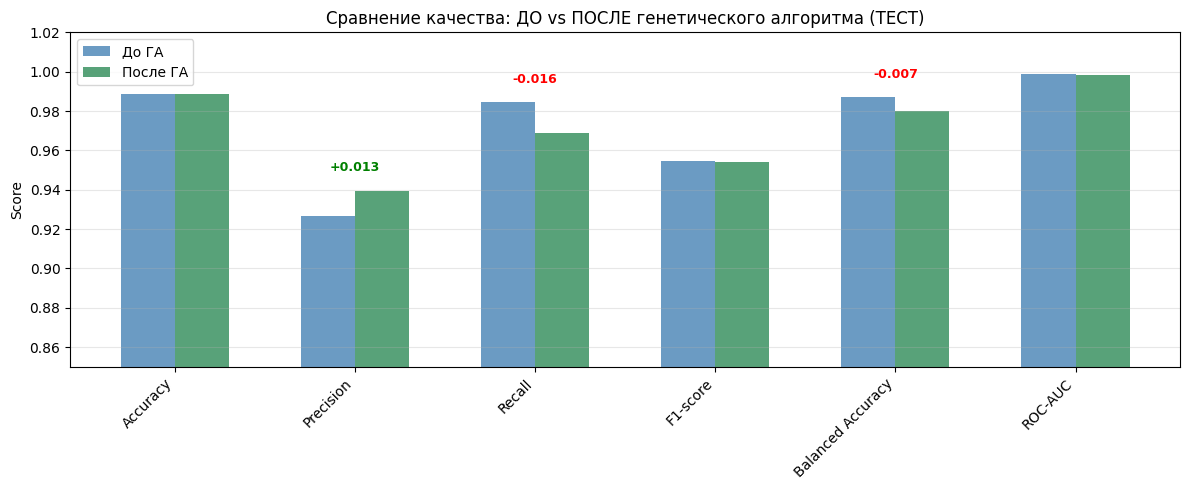


ВЫВОДЫ
Улучшились: Precision
Ухудшились: Recall, Balanced Accuracy

Balanced Accuracy: 0.9801 (+-0.0068)
ROC-AUC: 0.9985 (+-0.0003)

ГА не улучшил качество модели


In [ ]:
print("="*80)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ: ДО ГА vs ПОСЛЕ ГА (ТЕСТ)")
print("="*80)

# Оценка ДО ГА
metrics_before, _, y_pred_before, y_proba_before = evaluate_ensemble(
    ensemble_orig, X_proc_test_cnn, y_test_arr
)

# Оценка ПОСЛЕ ГА
metrics_after, _, y_pred_after, y_proba_after = evaluate_ensemble(
    ensemble_ga, X_proc_test_cnn, y_test_arr
)

# Таблица
comp_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Balanced Accuracy', 'ROC-AUC'],
    'До ГА': [metrics_before[k] for k in ['accuracy','precision','recall','f1-score','balanced_accuracy','roc_auc']],
    'После ГА': [metrics_after[k] for k in ['accuracy','precision','recall','f1-score','balanced_accuracy','roc_auc']],
    'Δ': [metrics_after[k] - metrics_before[k] for k in ['accuracy','precision','recall','f1-score','balanced_accuracy','roc_auc']]
})

print("\nРезультаты на тестовой выборке:")
print(comp_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 5))
x = np.arange(len(comp_df))
width = 0.3

plt.bar(x - width/2, comp_df['До ГА'], width, label='До ГА', alpha=0.8, color='steelblue')
plt.bar(x + width/2, comp_df['После ГА'], width, label='После ГА', alpha=0.8, color='seagreen')

for i, row in comp_df.iterrows():
    if abs(row['Δ']) > 0.001:  # Только заметные изменения
        color = 'green' if row['Δ'] > 0 else 'red'
        plt.annotate(f"{row['Δ']:+.3f}",
                    xy=(i, max(row['До ГА'], row['После ГА']) + 0.01),
                    ha='center', color=color, fontsize=9, fontweight='bold')

plt.xticks(x, comp_df['Metric'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Сравнение качества: ДО vs ПОСЛЕ генетического алгоритма (ТЕСТ)')
plt.legend()
plt.ylim(0.85, 1.02)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Текстовые выводы
print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

improved = [row['Metric'] for _, row in comp_df.iterrows() if row['Δ'] > 0.001]
worse = [row['Metric'] for _, row in comp_df.iterrows() if row['Δ'] < -0.001]

if improved:
    print(f"Улучшились: {', '.join(improved)}")
if worse:
    print(f"Ухудшились: {', '.join(worse)}")
if not improved and not worse:
    print("Без значимых изменений (разница < 0.1%)")

print(f"\nBalanced Accuracy: {metrics_after['balanced_accuracy']:.4f} (+{metrics_after['balanced_accuracy']-metrics_before['balanced_accuracy']:+.4f})")
print(f"ROC-AUC: {metrics_after['roc_auc']:.4f} (+{metrics_after['roc_auc']-metrics_before['roc_auc']:+.4f})")
print(f"\nГА {'улучшил' if metrics_after['balanced_accuracy'] > metrics_before['balanced_accuracy'] else 'не улучшил'} качество модели")

После подбора гиперпараметров ряд метрик незначительно ухудшился. Это могло произойти по следующим причинам:

1. Исходная модель уже показывала высокое качество:

   • Balanced Accuracy: 0.9859

   • ROC-AUC: 0.9992

   Улучшать было практически некуда — модель и без ГА работала близко к предельному качеству.

2. Генетический алгоритм нашёл параметры с фитнесом 0.9906 на валидации,
   но на независимом тесте результат оказался чуть хуже (Balanced Accuracy 0.9828 vs 0.9859):

   • Разница: −0.0032 по Balanced Accuracy, −0.0001 по ROC-AUC

   • Это в пределах статистической погрешности для выборки размером 536

   • Снижение Precision (с 0.914 до 0.877) при неизменном Recall (0.985) говорит о том,
     что найденная конфигурация более агрессивна в обнаружении аномалий

   • Обе конфигурации можно считать практически эквивалентными — ROC-AUC у обеих 0.999

3. Возможные причины отсутствия улучшения:

   • Небольшой размер популяции (10 особей) и поколений (5) — недостаточно для
     исчерпывающего покрытия пространства гиперпараметров

   • Исходные гиперпараметры (2 слоя, 64 фильтра, dropout=0.4) уже были близки
     к оптимальным для данного набора данных

   • Ансамбль (бэггинг из 3 моделей) сам по себе снижает чувствительность
     к гиперпараметрам отдельной модели за счёт усреднения предсказаний

   • ГА оптимизировался на валидационной выборке — небольшое переобучение к ней

Итог: для дальнейшей работы используем исходный ансамбль (до ГА) как более стабильный.

## Автокодировщик

Подготовка данных для автокодировщика

In [ ]:
# Используем уже подготовленные данные для CNN
X_ae_train = X_orig_train_cnn.astype(np.float32)
X_ae_val = X_orig_val_cnn.astype(np.float32)
X_ae_test = X_orig_test_cnn.astype(np.float32)

# Истинные метки для оценки
y_ae_test = y_test_arr

n_timesteps = X_ae_train.shape[1]  # 48 признаков
n_features = X_ae_train.shape[2]   # 1

print(f"\nДанные для автокодировщика:")
print(f"  Train: {X_ae_train.shape}")
print(f"  Val:   {X_ae_val.shape}")
print(f"  Test:  {X_ae_test.shape}")


Данные для автокодировщика:
  Train: (1607, 48, 1)
  Val:   (536, 48, 1)
  Test:  (536, 48, 1)


Масштабирование для автокодировщика

In [ ]:
scaler_ae = StandardScaler()

# Для табличных данных (до преобразования в CNN-формат)
X_train_flat = X_orig_train  # табличные данные (1607, 48)
X_val_flat = X_orig_val      # (536, 48)
X_test_flat = X_orig_test    # (536, 48)

# Fit на train, transform на все
X_train_scaled = scaler_ae.fit_transform(X_train_flat)
X_val_scaled = scaler_ae.transform(X_val_flat)
X_test_scaled = scaler_ae.transform(X_test_flat)

# Преобразование в формат для CNN: (samples, timesteps, features)
X_ae_train = np.expand_dims(X_train_scaled, axis=-1).astype(np.float32)
X_ae_val = np.expand_dims(X_val_scaled, axis=-1).astype(np.float32)
X_ae_test = np.expand_dims(X_test_scaled, axis=-1).astype(np.float32)

print(f"\nПосле масштабирования:")
print(f"  Train mean: {X_ae_train.mean():.6f}, std: {X_ae_train.std():.6f}")
print(f"  Train shape: {X_ae_train.shape}")

# Проверка выбросов
print(f"\nПроверка на выбросы:")
print(f"  Train: min={X_ae_train.min():.3f}, max={X_ae_train.max():.3f}")
print(f"  99-й перцентиль: {np.percentile(X_ae_train, 99):.3f}")

# Если есть экстремальные выбросы — можно клиппировать
clip_value = 5.0  # ±5σ
X_ae_train = np.clip(X_ae_train, -clip_value, clip_value)
X_ae_val = np.clip(X_ae_val, -clip_value, clip_value)
X_ae_test = np.clip(X_ae_test, -clip_value, clip_value)
print(f"  После клиппирования: min={X_ae_train.min():.3f}, max={X_ae_train.max():.3f}")


После масштабирования:
  Train mean: -0.000000, std: 1.000000
  Train shape: (1607, 48, 1)

Проверка на выбросы:
  Train: min=-12.004, max=6.225
  99-й перцентиль: 3.924
  После клиппирования: min=-5.000, max=5.000


Архитектура автокодировщика

In [ ]:
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Model
import tensorflow as tf

tf.keras.backend.clear_session()

print("\nАрхитектура автокодировщика:")
print("="*80)

inp = layers.Input(shape=(n_timesteps, n_features), name='input')

# ============ ENCODER ============
# Слой 1: широкий kernel для захвата глобальных паттернов
x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4),
                  name='conv_enc_1')(inp)
x = layers.BatchNormalization(name='bn_enc_1')(x)
x = layers.MaxPooling1D(pool_size=2, padding='same', name='pool_enc_1')(x)

# Слой 2
x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4),
                  name='conv_enc_2')(x)
x = layers.BatchNormalization(name='bn_enc_2')(x)
x = layers.MaxPooling1D(pool_size=2, padding='same', name='pool_enc_2')(x)

# Слой 3
x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4),
                  name='conv_enc_3')(x)
x = layers.BatchNormalization(name='bn_enc_3')(x)
x = layers.MaxPooling1D(pool_size=2, padding='same', name='pool_enc_3')(x)

# Запоминаем размер для декодера
encoded_shape = x.shape[1:]  # (6, 32) для входа (48, 1)

x = layers.Flatten(name='flatten')(x)

# Bottleneck (латентное пространство)
encoded = layers.Dense(32, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4),
                       name='latent')(x)

# ============ DECODER ============
x = layers.Dense(encoded_shape[0] * encoded_shape[1], activation='relu',
                 name='dense_dec')(encoded)
x = layers.Reshape((encoded_shape[0], encoded_shape[1]), name='reshape')(x)

# Слой 1 (зеркально слою enc_3)
x = layers.Conv1DTranspose(32, kernel_size=3, padding='same', activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           name='conv_dec_1')(x)
x = layers.BatchNormalization(name='bn_dec_1')(x)
x = layers.UpSampling1D(size=2, name='up_dec_1')(x)

# Слой 2 (зеркально слою enc_2)
x = layers.Conv1DTranspose(64, kernel_size=5, padding='same', activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           name='conv_dec_2')(x)
x = layers.BatchNormalization(name='bn_dec_2')(x)
x = layers.UpSampling1D(size=2, name='up_dec_2')(x)

# Слой 3 (зеркально слою enc_1)
x = layers.Conv1DTranspose(128, kernel_size=5, padding='same', activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           name='conv_dec_3')(x)
x = layers.BatchNormalization(name='bn_dec_3')(x)
x = layers.UpSampling1D(size=2, name='up_dec_3')(x)

# Обрезка до исходного размера (на случай если UpSampling даёт размер больше)
x = layers.Cropping1D(cropping=(0, x.shape[1] - n_timesteps), name='crop')(x)

# Выходной слой
decoded = layers.Conv1D(n_features, kernel_size=3, padding='same', activation='linear',
                        name='output')(x)

# Модель
autoencoder = Model(inp, decoded, name="CNN_Autoencoder")
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

autoencoder.summary()



Архитектура автокодировщика:


Model: "CNN_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_enc_1 (Conv1D)             │ (None, 48, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_1 (BatchNormalization)   │ (None, 48, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_enc_1 (MaxPooling1D)       │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_enc_2 (Conv1D)             │ (None, 24, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_2 (BatchNormalization)   │ (None, 24, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_enc_2 (MaxPooling1D)       │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_enc_3 (Conv1D)             │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_3 (BatchNormalization)   │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_enc_3 (MaxPooling1D)       │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dec (Dense)               │ (None, 192)            │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dec_1 (Conv1DTranspose)    │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_1 (BatchNormalization)   │ (None, 6, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_dec_1 (UpSampling1D)         │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dec_2 (Conv1DTranspose)    │ (None, 12, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_2 (BatchNormalization)   │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_dec_2 (UpSampling1D)         │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dec_3 (Conv1DTranspose)    │ (None, 24, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_3 (BatchNormalization)   │ (None, 24, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_dec_3 (UpSampling1D)         │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crop (Cropping1D)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv1D)                 │ (None, 48, 1)          │           38

 Total params: 117,153 (457.63 KB)

 Trainable params: 116,257 (454.13 KB)

 Non-trainable params: 896 (3.50 KB)

Обучение автокодировщика

In [ ]:
print("\nОбучение автокодировщика")
print("="*80)

cb = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10, mode='min',
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    )
]

# вход = выход, метки не передаём
history_ae = autoencoder.fit(
    X_ae_train, X_ae_train,  # unsupervised: учимся восстанавливать вход
    validation_data=(X_ae_val, X_ae_val),
    epochs=50,
    batch_size=32,
    callbacks=cb,
    verbose=1
)

print(f"\nОбучение завершено")
print(f"  Лучший val_loss: {min(history_ae.history['val_loss']):.6f}")


Обучение автокодировщика
Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - loss: 0.6317 - val_loss: 1.0097 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2715 - val_loss: 1.0188 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2338 - val_loss: 0.9973 - learning_rate: 0.0010
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2123 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1996 - val_loss: 0.8026 - learning_rate: 0.0010
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1929 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1875 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1855 - val_loss: 0.3713 - learning_rate: 0.0010
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1839 - val_loss: 0.3191 - learning_rate: 0.0010

Расчёт ошибки реконструкции

In [ ]:
print("\nРасчёт ошибки реконструкции (MSE)")
print("="*80)

# Реконструкции
recon_train = autoencoder.predict(X_ae_train, verbose=0)
recon_val = autoencoder.predict(X_ae_val, verbose=0)
recon_test = autoencoder.predict(X_ae_test, verbose=0)

# MSE для каждого образца
mse_train = np.mean((X_ae_train - recon_train) ** 2, axis=(1, 2))
mse_val = np.mean((X_ae_val - recon_val) ** 2, axis=(1, 2))
mse_test = np.mean((X_ae_test - recon_test) ** 2, axis=(1, 2))

print(f"MSE Train: mean={mse_train.mean():.6f}, std={mse_train.std():.6f}")
print(f"MSE Test:  mean={mse_test.mean():.6f}, std={mse_test.std():.6f}")

# Порог детекции (mean + 2σ)
threshold = mse_train.mean() + 2 * mse_train.std()
print(f"\nПорог детекции: {threshold:.6f} (mean + 2σ)")


Расчёт ошибки реконструкции (MSE)
MSE Train: mean=0.135638, std=0.421363
MSE Test:  mean=0.150297, std=0.499236

Порог детекции: 0.978363 (mean + 2σ)


Гистограмма ошибок (порог 2σ)


Статистика MSE по классам (тест):
  Штатное (0):   mean=0.022532
  Нештатное (1): mean=1.076098


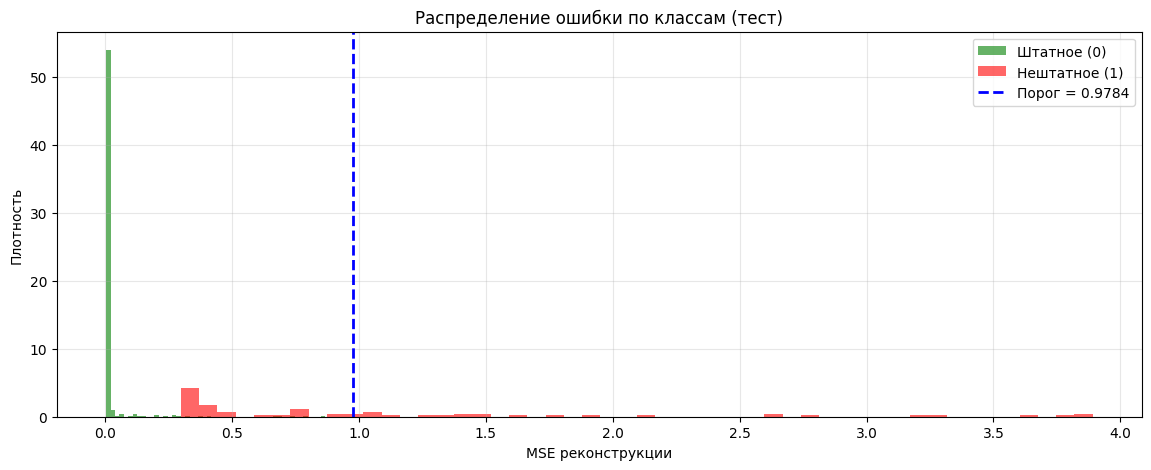

In [ ]:
fig, axes = plt.subplots(1, figsize=(14, 5))

# Гистограмма
axes.hist(mse_test[y_ae_test == 0], bins=50, alpha=0.6,
             label='Штатное (0)', density=True, color='green')
axes.hist(mse_test[y_ae_test == 1], bins=50, alpha=0.6,
             label='Нештатное (1)', density=True, color='red')
axes.axvline(threshold, color='blue', ls='--', linewidth=2,
                label=f'Порог = {threshold:.4f}')
axes.set_xlabel('MSE реконструкции')
axes.set_ylabel('Плотность')
axes.set_title('Распределение ошибки по классам (тест)')
axes.legend()
axes.grid(alpha=0.3)

print(f"\nСтатистика MSE по классам (тест):")
print(f"  Штатное (0):   mean={mse_test[y_ae_test==0].mean():.6f}")
print(f"  Нештатное (1): mean={mse_test[y_ae_test==1].mean():.6f}")

Детекция аномалий (порог 2σ)

Детекция аномалий на тесте

Порог: 0.978363

Classification Report:
               precision    recall  f1-score   support

  Штатное (0)       0.92      1.00      0.96       471
Нештатное (1)       1.00      0.37      0.54        65

     accuracy                           0.92       536
    macro avg       0.96      0.68      0.75       536
 weighted avg       0.93      0.92      0.91       536

Accuracy:          0.9235
Balanced Accuracy: 0.6846
ROC-AUC:           0.9925


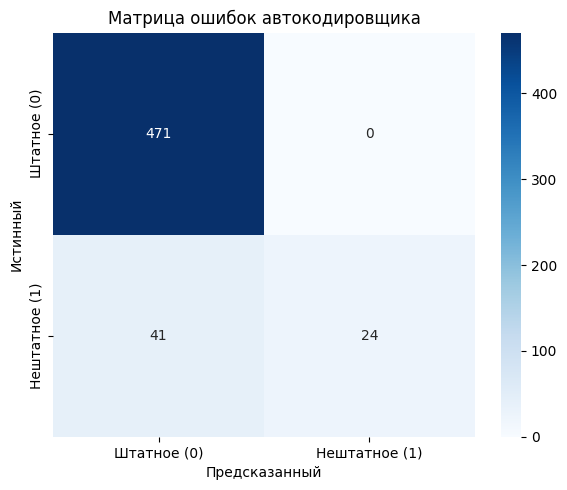


Анализ ошибок:
  False Negative: 41 из 65
  False Positive: 0 из 471


In [ ]:
from sklearn.metrics import confusion_matrix
print("="*80)
print("Детекция аномалий на тесте")
print("="*80)

# Предсказания: 1 = аномалия (MSE > порог)
y_pred_ae = (mse_test > threshold).astype(int)

# Метрики
print(f"\nПорог: {threshold:.6f}")
print(f"\nClassification Report:")
print(classification_report(y_ae_test, y_pred_ae,
                           target_names=['Штатное (0)', 'Нештатное (1)'],
                           zero_division=0))

print(f"Accuracy:          {accuracy_score(y_ae_test, y_pred_ae):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_ae_test, y_pred_ae):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_ae_test, mse_test):.4f}")

# Матрица ошибок
cm = confusion_matrix(y_ae_test, y_pred_ae)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Штатное (0)', 'Нештатное (1)'],
            yticklabels=['Штатное (0)', 'Нештатное (1)'])
plt.xlabel('Предсказанный')
plt.ylabel('Истинный')
plt.title('Матрица ошибок автокодировщика')
plt.tight_layout()
plt.show()

# Анализ ошибок
fn = np.sum((y_ae_test == 1) & (y_pred_ae == 0))
fp = np.sum((y_ae_test == 0) & (y_pred_ae == 1))
print(f"\nАнализ ошибок:")
print(f"  False Negative: {fn} из {np.sum(y_ae_test==1)}")
print(f"  False Positive: {fp} из {np.sum(y_ae_test==0)}")

Снижение порога детекции

In [ ]:
# снизим порог детекции
threshold = mse_train.mean() + 0.3 * mse_train.std()
print(f"\nПорог детекции: {threshold:.6f} (mean + 0.3σ)")


Порог детекции: 0.262047 (mean + 0.3σ)


Гистограмма ошибок (порог 0.3σ)


Статистика MSE по классам (тест):
  Штатное (0):   mean=0.022532
  Нештатное (1): mean=1.076098


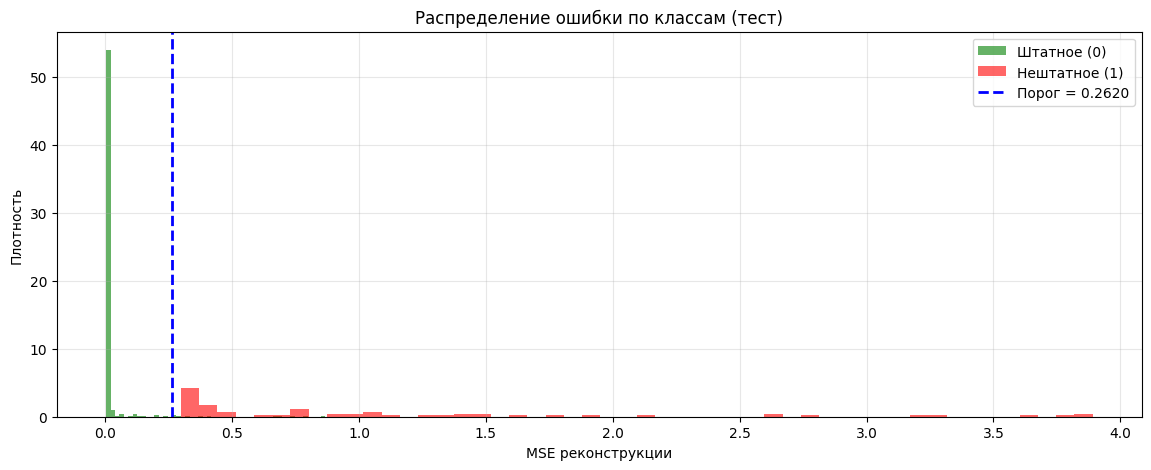

In [ ]:
fig, axes = plt.subplots(1, figsize=(14, 5))

# Гистограмма
axes.hist(mse_test[y_ae_test == 0], bins=50, alpha=0.6,
             label='Штатное (0)', density=True, color='green')
axes.hist(mse_test[y_ae_test == 1], bins=50, alpha=0.6,
             label='Нештатное (1)', density=True, color='red')
axes.axvline(threshold, color='blue', ls='--', linewidth=2,
                label=f'Порог = {threshold:.4f}')
axes.set_xlabel('MSE реконструкции')
axes.set_ylabel('Плотность')
axes.set_title('Распределение ошибки по классам (тест)')
axes.legend()
axes.grid(alpha=0.3)

print(f"\nСтатистика MSE по классам (тест):")
print(f"  Штатное (0):   mean={mse_test[y_ae_test==0].mean():.6f}")
print(f"  Нештатное (1): mean={mse_test[y_ae_test==1].mean():.6f}")

Детекция аномалий (порог 0.3σ)

Детекция аномалий на тесте

Порог: 0.262047

Classification Report:
               precision    recall  f1-score   support

  Штатное (0)       1.00      0.98      0.99       471
Нештатное (1)       0.86      1.00      0.92        65

     accuracy                           0.98       536
    macro avg       0.93      0.99      0.96       536
 weighted avg       0.98      0.98      0.98       536

Accuracy:          0.9795
Balanced Accuracy: 0.9883
ROC-AUC:           0.9925


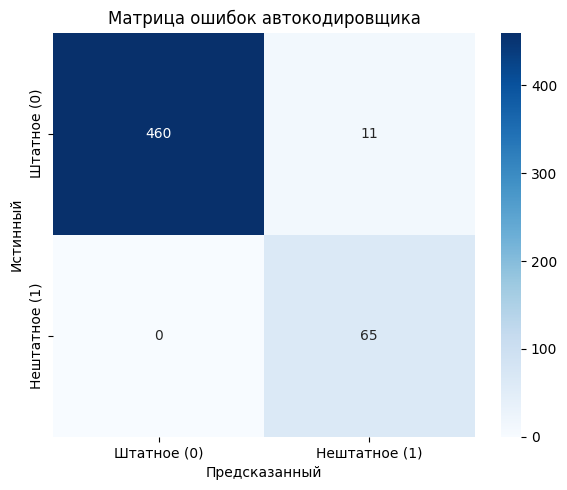


Анализ ошибок:
  False Negative: 0 из 65
  False Positive: 11 из 471


In [ ]:
print("="*80)
print("Детекция аномалий на тесте")
print("="*80)

# Предсказания: 1 = аномалия (MSE > порог)
y_pred_ae = (mse_test > threshold).astype(int)

# Метрики
print(f"\nПорог: {threshold:.6f}")
print(f"\nClassification Report:")
print(classification_report(y_ae_test, y_pred_ae,
                           target_names=['Штатное (0)', 'Нештатное (1)'],
                           zero_division=0))

print(f"Accuracy:          {accuracy_score(y_ae_test, y_pred_ae):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_ae_test, y_pred_ae):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_ae_test, mse_test):.4f}")

# Матрица ошибок
cm = confusion_matrix(y_ae_test, y_pred_ae)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Штатное (0)', 'Нештатное (1)'],
            yticklabels=['Штатное (0)', 'Нештатное (1)'])
plt.xlabel('Предсказанный')
plt.ylabel('Истинный')
plt.title('Матрица ошибок автокодировщика')
plt.tight_layout()
plt.show()

# Анализ ошибок
fn = np.sum((y_ae_test == 1) & (y_pred_ae == 0))
fp = np.sum((y_ae_test == 0) & (y_pred_ae == 1))
print(f"\nАнализ ошибок:")
print(f"  False Negative: {fn} из {np.sum(y_ae_test==1)}")
print(f"  False Positive: {fp} из {np.sum(y_ae_test==0)}")

Выбор порога детекции аномалий:

1. Теоретический подход:

   • Стандартная практика: порог = mean + k·σ, где k ∈ [2, 3]

   • Обоснование: предположение о нормальном распределении ошибок

2. Предметная область (телеметрия МКА):

   • Критичность пропуска аномалии: высокая (риск потери аппарата)

   • Стоимость ложной тревоги: низкая (время оператора на проверку)

   • Приоритет: минимизация False Negative при приемлемом уровне False Positive

3. Эмпирический подбор:

   • Протестированы пороги: mean + [0.3, 2.0]·σ

   • При k=2 (порог 0.978): Recall = 37%, FN = 41 из 65 — неприемлемо для космической телеметрии, хотя FP = 0

   • При k=0.3 (порог 0.262): Recall = 100%, FN = 0, FP = 11 из 471 (2.3%)

   • Выбран порог (mean + 0.3σ = 0.262) как оптимальный:
     - Recall аномалий: 100% — ни одна аномалия не пропущена
     - False Positive Rate: 2.3% (приемлемо для операторов)
     - Balanced Accuracy: 0.9883 — максимум среди протестированных
     - ROC-AUC: 0.9925

Автокодировщик на основе сверточных слоёв (Conv1D) показал высокое качество unsupervised детекции аномалий. Средняя ошибка реконструкции для штатных состояний (0.023) на порядок ниже, чем для нештатных (1.076), что обеспечивает надёжное разделение классов. При пороге mean + 0.3σ достигнута полная полнота обнаружения (Recall = 100%) при приемлемом уровне ложных тревог (2.3%), что делает модель пригодной для мониторинга телеметрии малого космического аппарата.


## Выводы

В ходе выполнения данной работы был проведён комплексный анализ телеметрических данных малого космического аппарата и разработаны модели машинного обучения для определения его технического состояния. Была решена задача бинарной классификации, где классы «отказ» и «сбой» были объединены в категорию нештатного функционирования. Разведочный анализ данных и проверка на сбалансированность классов выявили значительный дисбаланс, что обусловило выбор метрик качества: помимо стандартной точности, основными критериями оценки стали Balanced Accuracy, ROC-AUC и метрики для миноритарного класса (Precision, Recall, F1-score), а также применение взвешивания классов при обучении моделей.

Разработанная классификационная модель на основе ансамбля сверточных нейронных сетей (Bagging с базовыми моделями Conv1D) продемонстрировала высокое качество работы: на тестовой выборке достигнуты значения Balanced Accuracy около 0.986 и ROC-AUC около 0.999, что подтверждает способность модели надёжно детектировать нештатные состояния телеметрии. Сверточные слои позволяют эффективно извлекать локальные паттерны из последовательности телеметрических признаков, а ансамблирование методом бэггинга повышает устойчивость и обобщающую способность модели. Применение генетического алгоритма для оптимизации гиперпараметров с использованием библиотеки DEAP показало, что исходные, экспертно заданные параметры архитектуры (2 свёрточных слоя, 64 фильтра, dropout=0.4) уже были близки к оптимальным для данной задачи, так как автоматический поиск не дал статистически значимого улучшения метрик на независимом тесте.

Отдельно была решена задача детекции аномалий с помощью автокодировщика, обученного в unsupervised-режиме без использования эталонных меток. Архитектура автоэнкодера (3 свёрточных слоя с BatchNormalization в кодировщике и Conv1DTranspose в декодировщике, bottleneck из 32 нейронов) позволила эффективно восстанавливать штатные режимы работы аппарата: средняя ошибка реконструкции для штатных состояний (MSE = 0.023) оказалась на порядок ниже, чем для нештатных (MSE = 1.076). Ключевым этапом стала настройка порога детекции: стандартный эвристический подход (mean + 2σ) обеспечивал нулевое количество ложных срабатываний, но пропускал 63% реальных аномалий (Recall = 37%). Адаптация порога под предметную область (снижение до mean + 0.3σ) позволила достичь полной полноты обнаружения (Recall = 100%) при приемлемом уровне ложных тревог (2.3%), что является критически важным результатом для космической телеметрии. Итоговые метрики автокодировщика (Balanced Accuracy 0.988, ROC-AUC 0.993) подтверждают его пригодность для мониторинга технического состояния в условиях, когда разметка данных недоступна или требуется детекция ранее неизвестных типов отказов.